# Notebook 2 — Forecast Signal Discovery and Feature Engineering

## Overview

This notebook transitions from descriptive market analysis to predictive feature discovery. Rather than describing how Alberta's electricity market behaves, it evaluates which forecast-available variables appear most informative for predicting future pool prices and high-price conditions.

The notebook examines lead-lag relationships, information decay, nonlinear thresholds, interactions, market regimes, and candidate measures of system margin. Its purpose is to reduce a large collection of raw and engineered variables into a smaller, interpretable set of candidate forecasting features.

The analyses remain exploratory. Feature screening results do not establish causal importance or guarantee out-of-sample forecasting value. Formal model selection, tuning, and walk-forward evaluation are reserved for the next notebook.

## 1. Forecasting Framework

### 1.1. Import Libraries

In [1]:
# ---------------------------------------------------------------------
# Configure project imports and notebook environment
# ---------------------------------------------------------------------

from pathlib import Path
import sys
import warnings

PROJECT_ROOT = Path.cwd().parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

# ---------------------------------------------------------------------
# Import libraries
# ---------------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.feature_selection import (
    mutual_info_classif,
    mutual_info_regression,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    mean_absolute_error,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler

from config import RANDOM_SEED

# ---------------------------------------------------------------------
# Configure notebook settings
# ---------------------------------------------------------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", None)

np.random.seed(RANDOM_SEED)

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
)

### 1.2. Load the Canonical Master Dataset

In [2]:
# ---------------------------------------------------------------------
# Load the canonical master analytical dataset
# ---------------------------------------------------------------------

MASTER_PARQUET = (
    PROJECT_ROOT
    / "data"
    / "preprocessing"
    / "master"
    / "master_hourly.parquet"
)

if not MASTER_PARQUET.exists():
    raise FileNotFoundError(
        "Canonical master dataset not found at:\n"
        f"{MASTER_PARQUET}\n\n"
        "Run master_preprocessing.py with --overwrite or verify the output path."
    )

master = (
    pd.read_parquet(MASTER_PARQUET)
    .sort_values("timestamp_utc")
    .reset_index(drop=True)
)

master.head()

,timestamp_utc,timestamp_alberta,local_date,year_alberta,quarter_alberta,month_alberta,month_name_alberta,week_of_year_alberta,day_of_year_alberta,day_of_month_alberta,day_of_week_alberta,day_name_alberta,hour_alberta,utc_offset_hours,is_daylight_saving_time,is_weekday,is_weekend,is_month_start,is_month_end,is_quarter_start,is_quarter_end,is_year_start,is_year_end,holiday_name,is_holiday,is_day_before_holiday,is_day_after_holiday,is_business_day,season,is_heating_season,is_cooling_season,period_of_day,is_overnight,is_morning_ramp,is_business_hour,is_afternoon,is_evening_peak,is_late_evening,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,day_of_year_sin,day_of_year_cos,ail_mw,pool_price,gas_price,spark_spread,pa_available,hour_ahead_price_forecast,export_bc,export_mt,export_sk,import_bc,import_mt,import_sk,import_bc_raw,import_mt_raw,import_sk_raw,export_bc_raw,export_mt_raw,export_sk_raw,intertie_available,coal_outage,cogeneration_outage,combined_cycle_outage,dual_fuel_outage,gas_fired_steam_outage,hydro_outage,other_outage,simple_cycle_outage,solar_outage,storage_outage,wind_outage,total_outage_mw,outage_available,total_imports_mw,total_exports_mw,net_imports_mw,gross_interchange_mw,is_net_importing,is_net_exporting,total_imports_mw_lag_1h,total_imports_mw_lag_3h,total_imports_mw_lag_6h,total_imports_mw_lag_12h,total_imports_mw_lag_24h,total_imports_mw_change_1h,total_imports_mw_change_3h,total_imports_mw_change_6h,total_imports_mw_change_24h,total_exports_mw_lag_1h,total_exports_mw_lag_3h,total_exports_mw_lag_6h,total_exports_mw_lag_12h,total_exports_mw_lag_24h,total_exports_mw_change_1h,total_exports_mw_change_3h,total_exports_mw_change_6h,total_exports_mw_change_24h,net_imports_mw_lag_1h,net_imports_mw_lag_3h,net_imports_mw_lag_6h,net_imports_mw_lag_12h,net_imports_mw_lag_24h,net_imports_mw_change_1h,net_imports_mw_change_3h,net_imports_mw_change_6h,net_imports_mw_change_24h,thermal_outage_mw,renewable_outage_mw,storage_outage_mw,total_outage_mw_lag_1h,total_outage_mw_lag_3h,total_outage_mw_lag_6h,total_outage_mw_lag_12h,total_outage_mw_lag_24h,total_outage_mw_lag_48h,total_outage_mw_change_1h,total_outage_mw_change_3h,total_outage_mw_change_6h,total_outage_mw_change_24h,thermal_outage_mw_lag_1h,thermal_outage_mw_lag_3h,thermal_outage_mw_lag_6h,thermal_outage_mw_lag_12h,thermal_outage_mw_lag_24h,thermal_outage_mw_lag_48h,thermal_outage_mw_change_1h,thermal_outage_mw_change_3h,thermal_outage_mw_change_6h,thermal_outage_mw_change_24h,renewable_outage_mw_lag_1h,renewable_outage_mw_lag_3h,renewable_outage_mw_lag_6h,renewable_outage_mw_lag_12h,renewable_outage_mw_lag_24h,renewable_outage_mw_lag_48h,renewable_outage_mw_change_1h,renewable_outage_mw_change_3h,renewable_outage_mw_change_6h,renewable_outage_mw_change_24h,price_negative,price_above_100,price_above_300,price_above_500,price_above_900,price_at_cap,log1p_nonnegative_price,pool_price_lag_1h,pool_price_lag_2h,pool_price_lag_3h,pool_price_lag_6h,pool_price_lag_12h,pool_price_lag_24h,pool_price_lag_48h,pool_price_lag_168h,pool_price_change_1h,pool_price_change_3h,pool_price_change_6h,pool_price_change_12h,pool_price_change_24h,pool_price_mean_prior_3h,pool_price_std_prior_3h,pool_price_min_prior_3h,pool_price_max_prior_3h,pool_price_mean_prior_6h,pool_price_std_prior_6h,pool_price_min_prior_6h,pool_price_max_prior_6h,pool_price_mean_prior_24h,pool_price_std_prior_24h,pool_price_min_prior_24h,pool_price_max_prior_24h,pool_price_mean_prior_72h,pool_price_std_prior_72h,pool_price_min_prior_72h,pool_price_max_prior_72h,pool_price_mean_prior_168h,pool_price_std_prior_168h,pool_price_min_prior_168h,pool_price_max_prior_168h,ail_mw_lag_1h,ail_mw_lag_3h,ail_mw_lag_6h,ail_mw_lag_12h,ail_mw_lag_24h,ail_mw_lag_48h,ail_mw_lag_168h,ail_ramp_change_1h,ail_ramp_change_3h,ail_ramp_change_6h,ail_ramp_change_12h,ail_ramp_change_24h,ail_mw_mean_prior_3h,ail_mw_std_prior_3h,ail_mw_min_prior_3h,ail_mw_max_prior_3h,ail_mw_mean_prior_6h,ail_mw_std_prior_6h,ail_mw_min_prior

### 1.3. Forecasting Philosophy

Descriptive association and forecasting usefulness are not equivalent. A variable may be strongly associated with pool price contemporaneously while providing little information about prices several hours later. Conversely, a variable with modest contemporaneous correlation may become useful when represented through lags, changes, rolling windows, interactions, or regime-dependent effects.

This notebook follows five principles:

1. Targets always occur after the forecast origin. Future price and high-price labels are created by shifting the target backward relative to the current feature row.
2. Feature construction is time-aware. Historical price features and rolling statistics use only information available before or at the forecast origin.
3. The canonical master dataset is not modified. Targets and exploratory features are stored in separate analytical DataFrames.
4. Screening is not final validation. Full-sample correlations, mutual information, and tree-based importance are used to generate hypotheses, not to claim production performance.
5. Operational availability must be explicit. A variable observed at time \(t\) is not necessarily known sufficiently early to support an actual forecast made at time \(t\).

Formal walk-forward validation and model comparison are performed in the next notebook.

### 1.4. Define Forecast Horizons and Future Targets

In [3]:
# ---------------------------------------------------------------------
# Define forecasting horizons and future targets
# ---------------------------------------------------------------------

PRICE_COLUMN = "pool_price"
HIGH_PRICE_THRESHOLD = 200

forecast_horizons = [
    1,
    3,
    6,
    12,
    24,
]

target_df = pd.DataFrame({
    "timestamp_utc": master["timestamp_utc"],
    "year_alberta": master["year_alberta"],
})

for horizon in forecast_horizons:

    target_df[f"price_t{horizon}"] = (
        master[PRICE_COLUMN]
        .shift(-horizon)
    )

    target_df[f"high_price_t{horizon}"] = (
        master[PRICE_COLUMN]
        .shift(-horizon)
        .ge(HIGH_PRICE_THRESHOLD)
        .astype("float")
    )

    # Rows without a future target must remain missing rather than False.
    target_df.loc[
        target_df[f"price_t{horizon}"].isna(),
        f"high_price_t{horizon}",
    ] = np.nan

target_audit = []

for horizon in forecast_horizons:
    target_audit.append({
        "horizon_hours": horizon,
        "price_target_rows": int(
            target_df[f"price_t{horizon}"].notna().sum()
        ),
        "high_price_target_rows": int(
            target_df[f"high_price_t{horizon}"].notna().sum()
        ),
        "high_price_rate_pct": (
            target_df[f"high_price_t{horizon}"].mean()
            * 100
        ),
    })

display(
    pd.DataFrame(target_audit)
    .round({"high_price_rate_pct": 3})
)

,horizon_hours,price_target_rows,high_price_target_rows,high_price_rate_pct
0,1,87664,87664,6.172
1,3,87662,87662,6.173
2,6,87659,87659,6.173
3,12,87653,87653,6.173
4,24,87641,87641,6.174


### 1.5. Build the Base Forecasting Dataset

Only the historical pre-reporting solar period is set to zero.

In [ ]:
# ---------------------------------------------------------------------
# Construct analysis-only forecasting variables
# ---------------------------------------------------------------------

# First reported solar measurement
first_solar_reported = master.loc[
    master["solar_system_generation"].notna(),
    "timestamp_utc",
].min()

# Replace NaN's with 0s. 
solar_for_analysis = (
    master["solar_system_generation"]
    .where(
        master["timestamp_utc"].ge(first_solar_reported),
        0.0,
    )
)

# Net load creation. 
net_load = (
    master["ail_mw"]
    - master["wind_system_generation"]
    - solar_for_analysis
)

# Create the forecast base DataFrame.
forecast_base = pd.DataFrame({
    "timestamp_utc": master["timestamp_utc"],
    "year_alberta": master["year_alberta"],
    "month_alberta": master["month_alberta"],
    "hour_alberta": master["hour_alberta"],
    "day_of_week_alberta": master.get(
        "day_of_week_alberta",
        pd.Series(index=master.index, dtype="float"),
    ),
    "season": master.get(
        "season",
        pd.Series(index=master.index, dtype="object"),
    ),
    "is_weekend": master.get(
        "is_weekend",
        pd.Series(index=master.index, dtype="float"),
    ),
    "is_holiday": master.get(
        "is_holiday",
        pd.Series(index=master.index, dtype="float"),
    ),
    "price": master["pool_price"],
    "load": master["ail_mw"],
    "net_load": net_load,
    "wind": master["wind_system_generation"],
    "solar": solar_for_analysis,
    "imports": master["total_imports_mw"],
    "net_imports": master.get(
        "net_imports_mw",
        pd.Series(index=master.index, dtype="float"),
    ),
    "outages": master["total_outage_mw"],
    "gas": master["gas_price"],
})

# Add weather measures when available.
optional_weather_columns = {
    "temperature": "load_weighted_temperature_c",
    "wind_speed_weather": "load_weighted_wind_speed_100m_ms",
    "heating_degree_hours": "load_weighted_heating_degree_hours",
    "cooling_degree_hours": "load_weighted_cooling_degree_hours",
}

for short_name, master_column in optional_weather_columns.items():
    if master_column in master.columns:
        forecast_base[short_name] = master[master_column]

# Compile the forecast features with the targets into one DataFrame.
forecast_df = (
    forecast_base
    .merge(
        target_df.drop(
            columns=[
                "year_alberta",
            ]
        ),
        on="timestamp_utc",
        how="left",
        validate="one_to_one",
    )
)

# Create the forecast audit. 
forecast_audit = pd.Series({
    "rows": len(forecast_df),
    "columns": forecast_df.shape[1],
    "first_solar_reported": first_solar_reported,
    "pre_reporting_solar_hours_set_to_zero": int(
        master["timestamp_utc"]
        .lt(first_solar_reported)
        .sum()
    ),
    "net_load_missing_hours": int(
        forecast_df["net_load"].isna().sum()
    ),
    "master_columns_added": 0,
})

display(forecast_audit.to_frame("value"))

,value
rows,87665
columns,28
first_solar_reported,2017-12-05 07:00:00+00:00
pre_reporting_solar_hours_set_to_zero,25656
net_load_missing_hours,0
master_columns_added,0


### 1.6. Define Candidate Variables and Screening Metrics

In [ ]:
# ---------------------------------------------------------------------
# Define candidate variables for initial signal screening
# ---------------------------------------------------------------------

candidate_variables = [
    "load",
    "net_load",
    "wind",
    "solar",
    "imports",
    "net_imports",
    "outages",
    "gas",
]

# Keeping only variables that actually exist and contain at least one observation.
candidate_variables = [
    variable
    for variable in candidate_variables
    if variable in forecast_df.columns
    and forecast_df[variable].notna().any()
]

def safe_auc(y_true, score):
    """
    Return ROC AUC when both target classes are present.
    """
    # Can score prescore separate between y_true True/False. 
    sample = pd.DataFrame({
        "target": y_true,
        "score": score,
    }).dropna()

    # Return NaN if there are no positive samples. 
    if sample["target"].nunique() < 2:
        return np.nan

    return roc_auc_score(
        sample["target"],
        sample["score"],
    )

def oriented_auc(y_true, score):
    """
    Return AUC in the more informative orientation.

    A value below 0.5 means the feature is inversely associated with
    the target. Flipping the orientation preserves signal strength.
    """
    auc = safe_auc(y_true, score)

    if pd.isna(auc):
        return np.nan

    return max(auc, 1 - auc)

# Electrcity price spikes are rare. 
# ROC AUC can sometimes look overly optimistic on imbalanced datasets. 
# Average precision focuses much more on "can the model identify the rare events?".
def safe_average_precision(y_true, score):
    sample = pd.DataFrame({
        "target": y_true,
        "score": score,
    }).dropna()

    if sample["target"].nunique() < 2:
        return np.nan

    return average_precision_score(
        sample["target"],
        sample["score"],
    )

## 2. Lead-lag Relationships

### 2.1. Cross-Correlation Overview

This compares the current candidate variable at time \(t\) with future price at \(t+h\).

In [ ]:
# ---------------------------------------------------------------------
# Compare candidate variables with future price across horizons
# ---------------------------------------------------------------------

lead_relationships = []

for variable in candidate_variables:
    for horizon in forecast_horizons:

        sample = forecast_df[
            [
                variable,
                f"price_t{horizon}",
                f"high_price_t{horizon}",
            ]
        ].dropna()

        lead_relationships.append({
            "variable": variable,
            "horizon_hours": horizon,
            "observations": len(sample),
            # Linear relationship. 
            "pearson_price": (
                sample[variable]
                .corr(
                    sample[f"price_t{horizon}"],
                    method="pearson",
                )
            ),
            # Monotonic rank relationships.
            "spearman_price": (
                sample[variable]
                .corr(
                    sample[f"price_t{horizon}"],
                    method="spearman",
                )
            ),
            # Scarcity ranking ability. 
            "oriented_auc": oriented_auc(
                sample[f"high_price_t{horizon}"],
                sample[variable],
            ),
        })

lead_relationships = pd.DataFrame(lead_relationships)

display(
    lead_relationships
    .sort_values(
        ["horizon_hours", "oriented_auc"],
        ascending=[True, False],
    )
    .round(3)
)

,variable,horizon_hours,observations,pearson_price,spearman_price,oriented_auc
5,net_load,1,87664,0.294,0.418,0.768
20,imports,1,87664,0.243,0.496,0.736
0,load,1,87664,0.260,0.432,0.728
15,solar,1,87664,0.163,0.416,0.718
25,net_imports,1,87664,0.209,0.383,0.716
10,wind,1,87664,-0.165,-0.127,0.704
35,gas,1,87664,0.250,0.392,0.692
30,outages,1,87664,0.117,0.098,0.629
16,solar,3,87662,0.234,0.425,0.735
6,net_load,3,87662,0.243,0.351,0.719


#### Lead-Lag Relationships:

The lead-lag analysis provides encouraging evidence that the selected market variables contain meaningful predictive information prior to any feature engineering or model training. Among all candidate variables, net load emerges as the strongest short-term predictor of future electricity prices and high-price events, outperforming raw system load across most forecasting horizons. This aligns well with market fundamentals, as net load represents the demand that must ultimately be met by dispatchable generation after accounting for renewable production.

One of the more interesting findings is the strength of imports as a forecasting signal. Imports consistently rank among the strongest predictors across multiple horizons, suggesting that intertie flows capture important information about regional supply-demand conditions and emerging market tightness. This warrants further investigation during later stages of feature engineering.

The gas price exhibits remarkably stable predictive performance across all forecast horizons. Unlike operational variables that change substantially from hour to hour, gas prices evolve more gradually and therefore appear to provide a persistent structural signal rather than a short-term operational one. This consistency suggests that fuel costs establish an underlying pricing environment while shorter-term market dynamics determine individual price movements.

The relationship between wind generation and future prices behaves exactly as expected from electricity market theory. Higher wind output is associated with lower future prices, reflecting the reduced reliance on higher-cost dispatchable generation when renewable production is abundant. Although the relationship is negative, the oriented AUC confirms that wind still contains meaningful predictive information.

Perhaps the most surprising result is the performance of solar generation, which demonstrates predictive strength comparable to several core market variables. While some of this relationship likely reflects the direct impact of renewable generation on market supply, it is also likely capturing broader daily and seasonal patterns. Consequently, solar should be interpreted as both an operational variable and a proxy for recurring temporal effects.

A notable pattern across several variables is the decline in predictive strength between the 6- and 12-hour horizons followed by a recovery at the 24-hour horizon. This rebound strongly suggests the presence of daily seasonality within Alberta's electricity market, where conditions observed today become informative again at approximately the same hour on the following day. This provides strong motivation for including lagged features at 24-hour and 168-hour intervals during subsequent feature engineering.

Finally, Spearman correlations consistently exceed Pearson correlations for many variables, indicating that the relationships with future prices are often monotonic but nonlinear rather than strictly linear. This is consistent with electricity market behaviour, where prices frequently remain stable before increasing rapidly as the system approaches scarcity. As a result, nonlinear machine learning methods such as gradient boosting are likely to exploit these relationships more effectively than purely linear models.

### 2.2. Detailed Lag Structure

In [7]:
# ---------------------------------------------------------------------
# Define reusable lag-screening analysis
# ---------------------------------------------------------------------

def evaluate_lag_structure(
    data,
    variable,
    horizons,
    max_lag=48,
):
    """
    Evaluate historical values of one variable against future targets.

    lag=0 uses the value observed at forecast origin t.
    lag=1 uses the value observed at t-1.
    """

    results = []

    for lag in range(max_lag + 1):

        lagged_feature = data[variable].shift(lag)

        for horizon in horizons:

            sample = pd.DataFrame({
                "feature": lagged_feature,
                "future_price": data[f"price_t{horizon}"],
                "future_high_price": data[
                    f"high_price_t{horizon}"
                ],
            }).dropna()

            results.append({
                "variable": variable,
                "lag_hours": lag,
                "horizon_hours": horizon,
                "observations": len(sample),
                "pearson_price": (
                    sample["feature"]
                    .corr(
                        sample["future_price"],
                        method="pearson",
                    )
                ),
                "spearman_price": (
                    sample["feature"]
                    .corr(
                        sample["future_price"],
                        method="spearman",
                    )
                ),
                "oriented_auc": oriented_auc(
                    sample["future_high_price"],
                    sample["feature"],
                ),
            })

    return pd.DataFrame(results)

In [8]:
# ---------------------------------------------------------------------
# Evaluate detailed lag structures for selected variables
# ---------------------------------------------------------------------

lag_variables = [
    variable
    for variable in [
        "net_load",
        "imports",
        "wind",
        "gas",
        "outages",
    ]
    if variable in forecast_df.columns
]

lag_results = pd.concat(
    [
        evaluate_lag_structure(
            forecast_df,
            variable=variable,
            horizons=forecast_horizons,
            max_lag=48,
        )
        for variable in lag_variables
    ],
    ignore_index=True,
)

display(
    lag_results
    .sort_values(
        "oriented_auc",
        ascending=False,
    )
    .head(25)
    .round(3)
)

,variable,lag_hours,horizon_hours,observations,pearson_price,spearman_price,oriented_auc
0,net_load,0,1,87664,0.294,0.418,0.768
5,net_load,1,1,87663,0.270,0.387,0.744
245,imports,0,1,87664,0.243,0.496,0.736
250,imports,1,1,87663,0.234,0.489,0.727
10,net_load,2,1,87662,0.243,0.351,0.719
1,net_load,0,3,87662,0.243,0.351,0.719
255,imports,2,1,87662,0.224,0.479,0.716
246,imports,0,3,87662,0.224,0.479,0.716
251,imports,1,3,87661,0.212,0.468,0.704
260,imports,3,1,87661,0.212,0.468,0.704


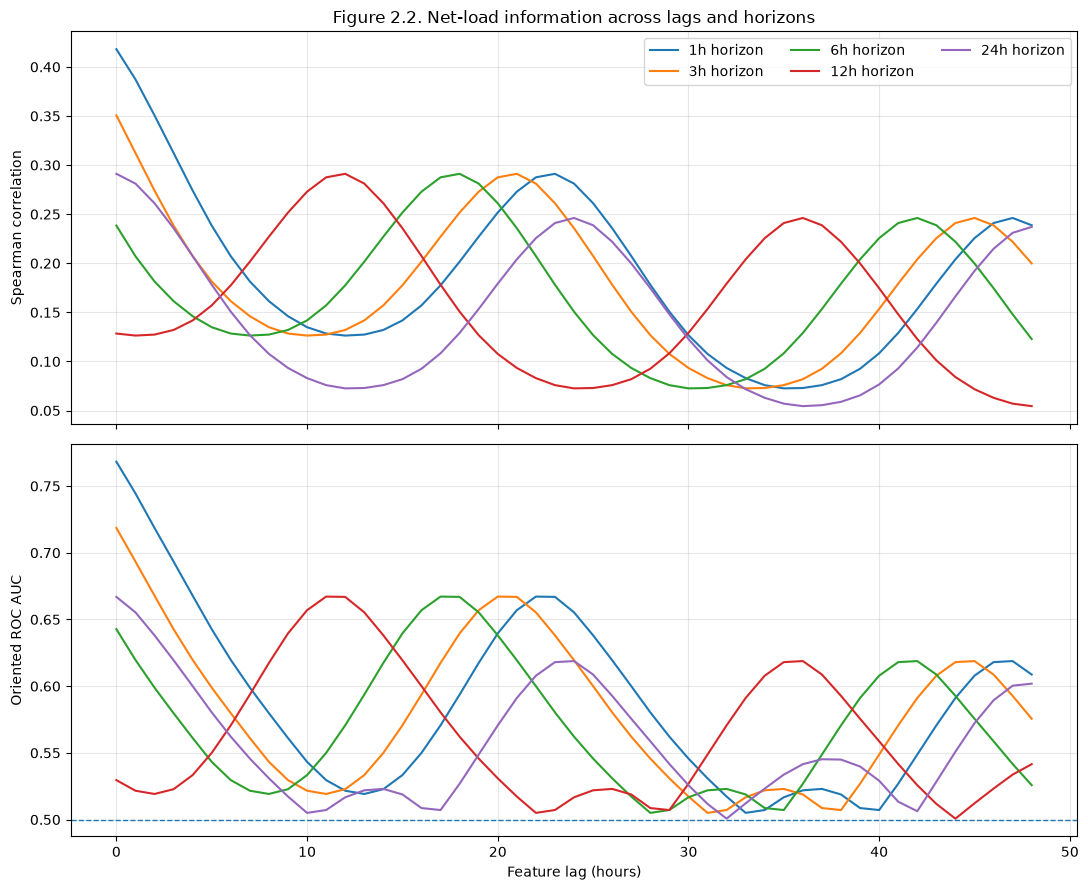

In [9]:
# ---------------------------------------------------------------------
# Visualize net-load lag structure
# ---------------------------------------------------------------------

variable = "net_load"

fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 9),
    sharex=True,
)

for horizon in forecast_horizons:

    subset = lag_results.loc[
        lag_results["variable"].eq(variable)
        & lag_results["horizon_hours"].eq(horizon)
    ]

    axes[0].plot(
        subset["lag_hours"],
        subset["spearman_price"],
        label=f"{horizon}h horizon",
    )

    axes[1].plot(
        subset["lag_hours"],
        subset["oriented_auc"],
        label=f"{horizon}h horizon",
    )

axes[0].set_title(
    "Figure 2.2. Net-load information across lags and horizons"
)
axes[0].set_ylabel("Spearman correlation")
axes[0].grid(alpha=0.3)
axes[0].legend(ncol=3)

axes[1].set_xlabel("Feature lag (hours)")
axes[1].set_ylabel("Oriented ROC AUC")
axes[1].axhline(0.5, linewidth=1, linestyle="--")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.3. Imports Lead Structure

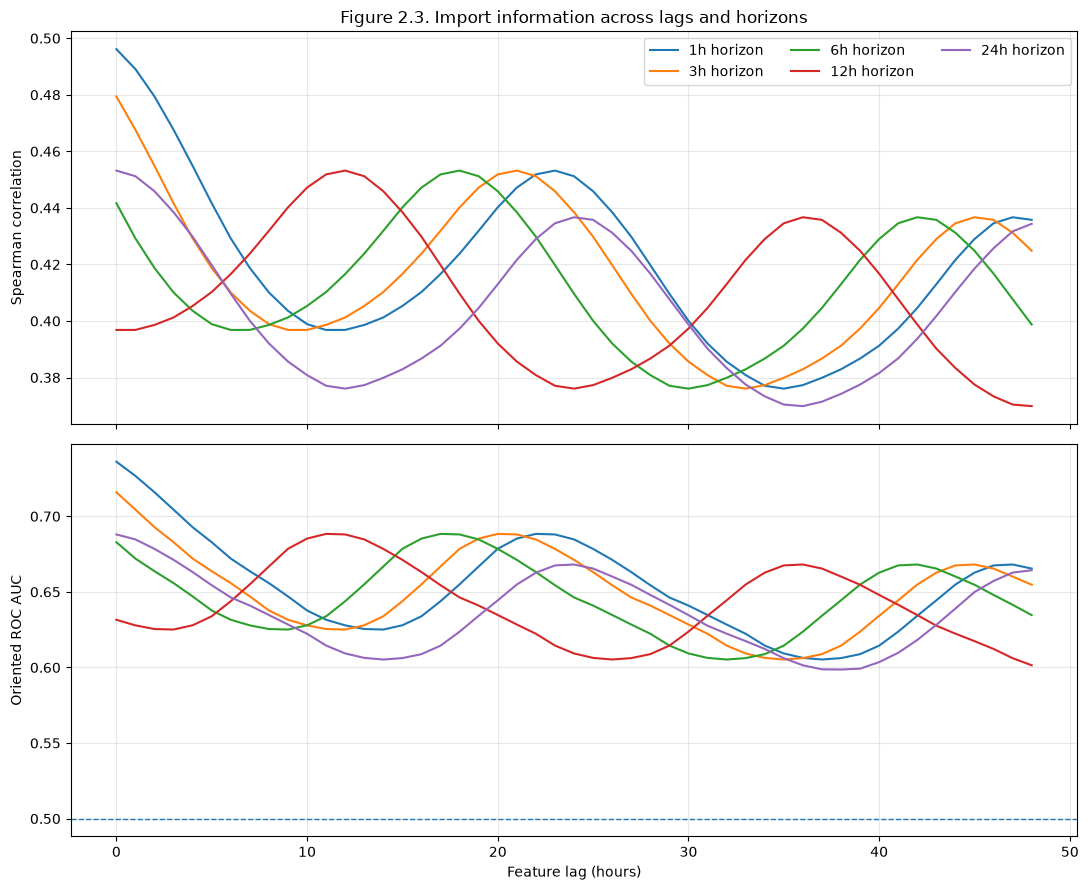

In [10]:
# ---------------------------------------------------------------------
# Visualize import lag structure
# ---------------------------------------------------------------------

variable = "imports"

fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 9),
    sharex=True,
)

for horizon in forecast_horizons:

    subset = lag_results.loc[
        lag_results["variable"].eq(variable)
        & lag_results["horizon_hours"].eq(horizon)
    ]

    axes[0].plot(
        subset["lag_hours"],
        subset["spearman_price"],
        label=f"{horizon}h horizon",
    )

    axes[1].plot(
        subset["lag_hours"],
        subset["oriented_auc"],
        label=f"{horizon}h horizon",
    )

axes[0].set_title(
    "Figure 2.3. Import information across lags and horizons"
)
axes[0].set_ylabel("Spearman correlation")
axes[0].grid(alpha=0.3)
axes[0].legend(ncol=3)

axes[1].set_xlabel("Feature lag (hours)")
axes[1].set_ylabel("Oriented ROC AUC")
axes[1].axhline(0.5, linewidth=1, linestyle="--")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.4. Wind Lead Structure

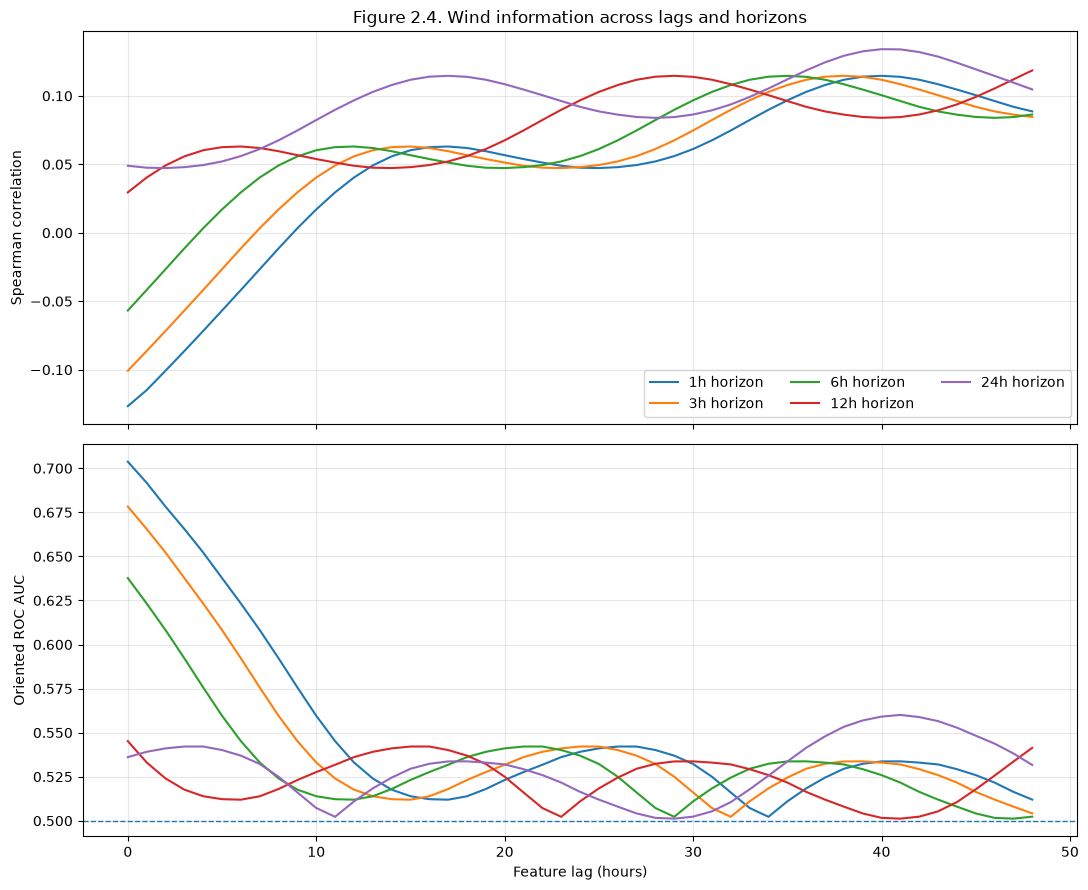

In [11]:
# ---------------------------------------------------------------------
# Visualize wind-generation lag structure
# ---------------------------------------------------------------------

variable = "wind"

fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 9),
    sharex=True,
)

for horizon in forecast_horizons:

    subset = lag_results.loc[
        lag_results["variable"].eq(variable)
        & lag_results["horizon_hours"].eq(horizon)
    ]

    axes[0].plot(
        subset["lag_hours"],
        subset["spearman_price"],
        label=f"{horizon}h horizon",
    )

    axes[1].plot(
        subset["lag_hours"],
        subset["oriented_auc"],
        label=f"{horizon}h horizon",
    )

axes[0].set_title(
    "Figure 2.4. Wind information across lags and horizons"
)
axes[0].set_ylabel("Spearman correlation")
axes[0].grid(alpha=0.3)
axes[0].legend(ncol=3)

axes[1].set_xlabel("Feature lag (hours)")
axes[1].set_ylabel("Oriented ROC AUC")
axes[1].axhline(0.5, linewidth=1, linestyle="--")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.5. Gas Lead Structure

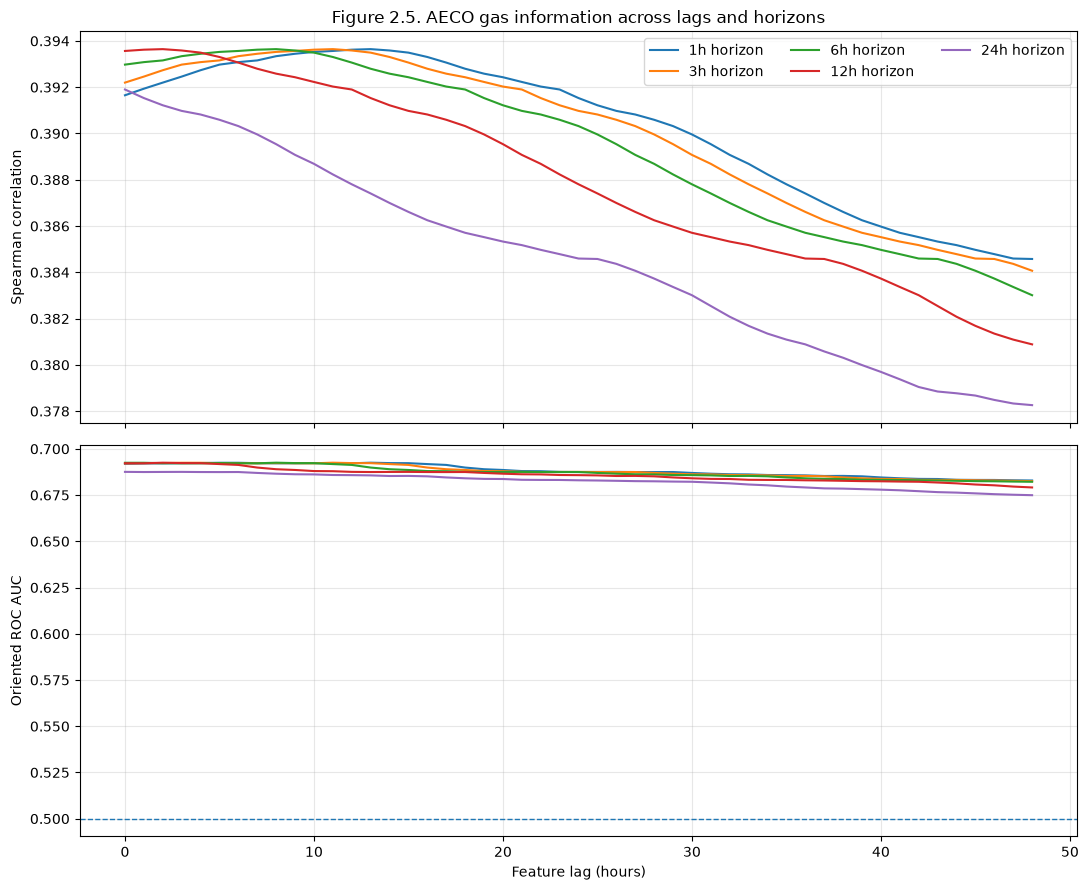

In [12]:
# ---------------------------------------------------------------------
# Visualize AECO gas-price lag structure
# ---------------------------------------------------------------------

variable = "gas"

fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 9),
    sharex=True,
)

for horizon in forecast_horizons:

    subset = lag_results.loc[
        lag_results["variable"].eq(variable)
        & lag_results["horizon_hours"].eq(horizon)
    ]

    axes[0].plot(
        subset["lag_hours"],
        subset["spearman_price"],
        label=f"{horizon}h horizon",
    )

    axes[1].plot(
        subset["lag_hours"],
        subset["oriented_auc"],
        label=f"{horizon}h horizon",
    )

axes[0].set_title(
    "Figure 2.5. AECO gas information across lags and horizons"
)
axes[0].set_ylabel("Spearman correlation")
axes[0].grid(alpha=0.3)
axes[0].legend(ncol=3)

axes[1].set_xlabel("Feature lag (hours)")
axes[1].set_ylabel("Oriented ROC AUC")
axes[1].axhline(0.5, linewidth=1, linestyle="--")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.6. Outage Lead Structure

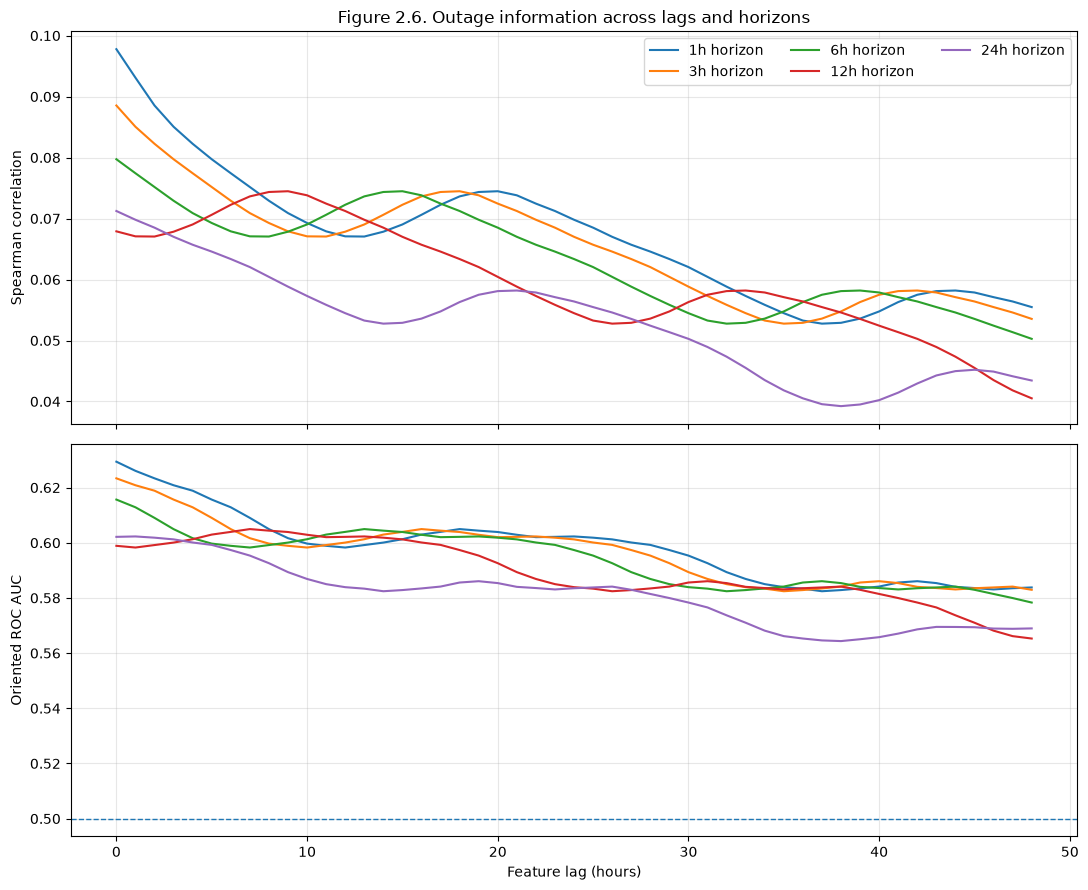

In [13]:
# ---------------------------------------------------------------------
# Visualize outage lag structure
# ---------------------------------------------------------------------

variable = "outages"

fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 9),
    sharex=True,
)

for horizon in forecast_horizons:

    subset = lag_results.loc[
        lag_results["variable"].eq(variable)
        & lag_results["horizon_hours"].eq(horizon)
    ]

    axes[0].plot(
        subset["lag_hours"],
        subset["spearman_price"],
        label=f"{horizon}h horizon",
    )

    axes[1].plot(
        subset["lag_hours"],
        subset["oriented_auc"],
        label=f"{horizon}h horizon",
    )

axes[0].set_title(
    "Figure 2.6. Outage information across lags and horizons"
)
axes[0].set_ylabel("Spearman correlation")
axes[0].grid(alpha=0.3)
axes[0].legend(ncol=3)

axes[1].set_xlabel("Feature lag (hours)")
axes[1].set_ylabel("Oriented ROC AUC")
axes[1].axhline(0.5, linewidth=1, linestyle="--")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.7. Lead-Lag Summary Table

In [14]:
# ---------------------------------------------------------------------
# Identify the strongest lag for each variable and horizon
# ---------------------------------------------------------------------

best_lag_summary = (
    lag_results
    .sort_values(
        "oriented_auc",
        ascending=False,
    )
    .groupby(
        [
            "variable",
            "horizon_hours",
        ],
        as_index=False,
    )
    .first()
    .sort_values(
        [
            "horizon_hours",
            "oriented_auc",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

display(
    best_lag_summary[
        [
            "variable",
            "horizon_hours",
            "lag_hours",
            "spearman_price",
            "oriented_auc",
            "observations",
        ]
    ]
    .round(3)
)

,variable,horizon_hours,lag_hours,spearman_price,oriented_auc,observations
10,net_load,1,0,0.418,0.768,87664
5,imports,1,0,0.496,0.736,87664
20,wind,1,0,-0.127,0.704,87664
0,gas,1,13,0.394,0.693,87651
15,outages,1,0,0.098,0.629,87664
11,net_load,3,0,0.351,0.719,87662
6,imports,3,0,0.479,0.716,87662
1,gas,3,11,0.394,0.693,87651
21,wind,3,0,-0.101,0.678,87662
16,outages,3,0,0.089,0.623,87662


#### Detailed Lag Structure

The lag structure analysis extends the initial lead-lag analysis by evaluating whether historical values of candidate variables provide additional predictive information beyond the current observed value. Rather than only examining the relationship between current market conditions and future prices, this analysis tests how observations from the previous 48 hours relate to future electricity prices and high-price events across multiple forecasting horizons.

The results confirm that net load remains the strongest operational predictor of short-term electricity prices. The highest-performing relationship occurs between current net load and the one-hour-ahead price target, with an oriented AUC of approximately 0.77. This indicates that the current balance between electricity demand and renewable generation contains substantial information about near-term market conditions. However, predictive strength declines as older net load observations are introduced, suggesting that net load behaves primarily as a short-memory operational variable. The most valuable historical information is concentrated within the most recent few hours, making recent net load lags strong candidates for feature engineering.

Imports demonstrate a similar short-term predictive pattern and emerge as a particularly valuable signal. Current imports provide strong predictive performance, with lagged import values from the previous several hours maintaining meaningful information about future prices. This suggests that intertie flows capture important information about Alberta's current supply-demand balance and the degree to which the province relies on external electricity supply. Further investigation of import-related variables may reveal additional market structure information, particularly during periods of system tightness.

Wind generation behaves consistently with electricity market fundamentals. Current wind output is negatively associated with future prices, reflecting the price-suppressing effect of renewable generation by reducing the need for higher-cost dispatchable generation. However, historical wind observations provide substantially less additional information, suggesting that wind is primarily valuable as a measure of current system conditions rather than a variable with significant temporal persistence.

Gas price exhibits a fundamentally different lag structure. Nearly identical predictive performance is observed across many gas price lags and forecasting horizons, indicating that gas prices act as a slow-moving structural variable rather than a short-term operational signal. Because gas prices change gradually over time, historical gas observations contain largely redundant information. As a result, feature engineering should likely prioritize the current gas price rather than introducing many lagged versions.

An important observation is that strong 24-hour lag relationships do not appear among the top-performing predictors despite evidence of daily seasonality in the previous analysis. This suggests that the daily structure of Alberta electricity prices is likely driven less by yesterday's operational conditions and more by recurring temporal patterns such as hour of day, day of week, seasonal demand patterns, and renewable generation cycles. This supports the inclusion of calendar-based features and seasonal indicators alongside operational variables.

Overall, the lag analysis suggests that different market variables contain information over different time scales. Net load, imports, and wind provide short-term operational signals that decay over several hours, while gas price provides a slower structural signal. These results provide guidance for subsequent feature engineering by identifying which lagged variables are likely to add meaningful forecasting value and which are likely to introduce redundant information.

#### Lead-Lag Summary

The lead-lag analysis distinguishes variables that remain informative several hours in advance from variables whose association is primarily contemporaneous. Particular attention should be paid to whether imports lose information rapidly when lagged, which would support the hypothesis that they respond to already-tight Alberta conditions rather than consistently leading them.

The strongest lag identified in the full sample should not be interpreted as the universally optimal lag. Later validation must test whether the selected lag remains informative in future years and across changing market regimes.

### Research Questions Generated from Initial Signal Analysis

The initial feature screening and lag analysis validate several core market relationships, but also reveal areas where the current variables may be incomplete representations of the underlying market mechanisms. The following questions will guide subsequent feature engineering and refinement:

- Does total outage capacity adequately represent generation scarcity, or should outages be separated by generator type (e.g., simple-cycle gas, combined-cycle gas, coal) to better capture their impact on available supply?

- Does net load alone sufficiently capture system tightness, or would a thermal capacity margin / reserve margin metric better represent the relationship between available dispatchable generation and residual demand?

- Are imports predictive because of their absolute magnitude, or because they represent system stress? Would normalized measures such as imports as a percentage of load, imports relative to historical conditions, or available intertie margin provide additional signal?

- Does gas price directly capture fuel-driven price formation, or would market-oriented variables such as spark spread, estimated marginal generation cost, or fuel cost pressure better represent the relationship between fuel costs and pool prices?

- Are renewable variables such as wind and solar valuable primarily because of their direct impact on supply, or because they act as proxies for broader weather and seasonal patterns?

- Do ramping features (e.g., changes in net load, wind output, or imports over recent hours) provide additional information about rapidly changing system conditions?

- Are scarcity events better represented through absolute thresholds (e.g., high net load) or through relative measures such as historical percentiles and deviations from normal operating conditions?

- Does the predictive value of operational variables change across different market regimes, such as normal conditions versus scarcity periods?

- Are interactions between variables more informative than individual features (e.g., high net load combined with low available thermal capacity, or high demand combined with low renewable output)?

- Which additional features can better translate the physical and economic mechanisms identified in the market analysis into measurable forecasting variables?

## 3. Information Decay

### 3.1 Lag Memory Curves

This condenses every horizon into the strongest AUC available at each lag.


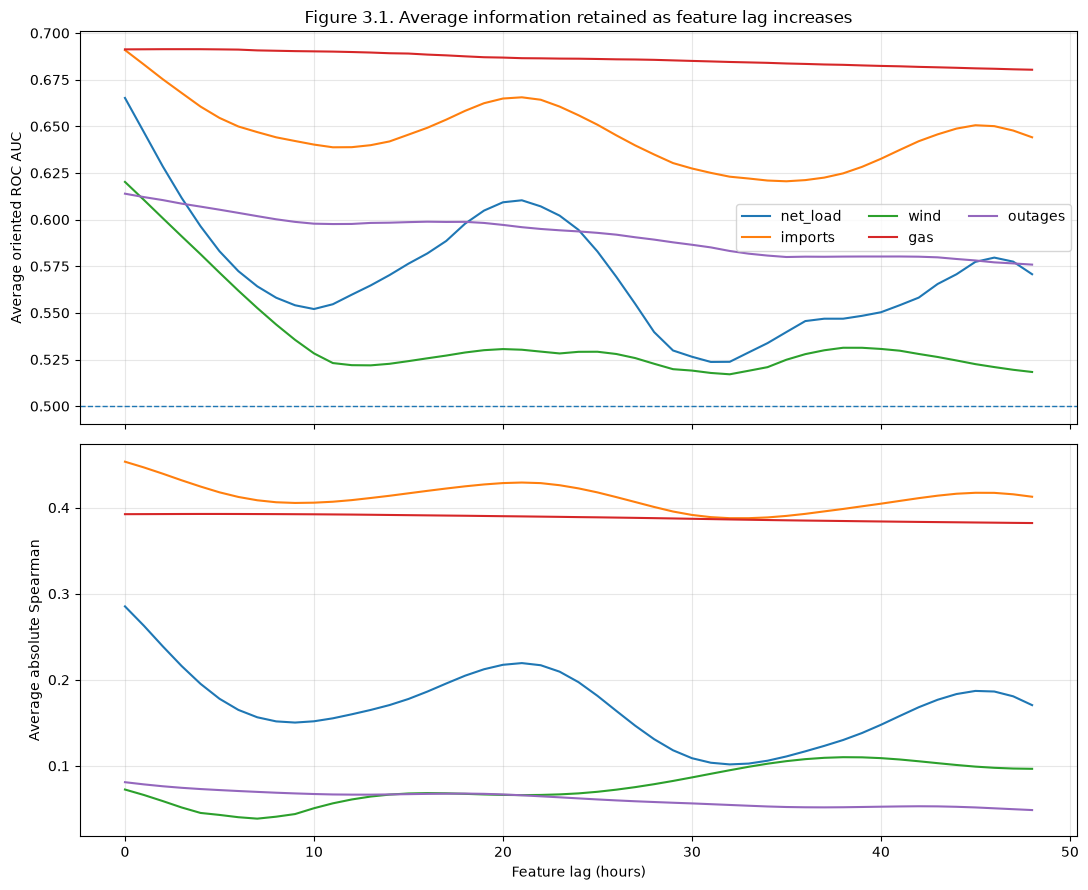

In [15]:
# ---------------------------------------------------------------------
# Summarize information decay by feature lag
# ---------------------------------------------------------------------

lag_memory = (
    lag_results
    .groupby(
        [
            "variable",
            "lag_hours",
        ],
        as_index=False,
    )
    .agg(
        average_oriented_auc=(
            "oriented_auc",
            "mean",
        ),
        maximum_oriented_auc=(
            "oriented_auc",
            "max",
        ),
        average_absolute_spearman=(
            "spearman_price",
            lambda series: series.abs().mean(),
        ),
    )
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 9),
    sharex=True,
)

for variable in lag_variables:

    subset = lag_memory.loc[
        lag_memory["variable"].eq(variable)
    ]

    axes[0].plot(
        subset["lag_hours"],
        subset["average_oriented_auc"],
        label=variable,
    )

    axes[1].plot(
        subset["lag_hours"],
        subset["average_absolute_spearman"],
        label=variable,
    )

axes[0].set_title(
    "Figure 3.1. Average information retained as feature lag increases"
)
axes[0].set_ylabel("Average oriented ROC AUC")
axes[0].axhline(0.5, linewidth=1, linestyle="--")
axes[0].grid(alpha=0.3)
axes[0].legend(ncol=3)

axes[1].set_xlabel("Feature lag (hours)")
axes[1].set_ylabel("Average absolute Spearman")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2. Rolling-Window Features

All windows are shifted one hour so they use information through \(t-1\).

In [16]:
# ---------------------------------------------------------------------
# Construct lagged rolling-window features
# ---------------------------------------------------------------------

rolling_windows = [
    3,
    6,
    12,
    24,
    72,
]

rolling_source_variables = [
    "price",
    "load",
    "net_load",
    "wind",
    "imports",
    "outages",
    "gas",
]

rolling_source_variables = [
    variable
    for variable in rolling_source_variables
    if variable in forecast_df.columns
]

rolling_features = pd.DataFrame({
    "timestamp_utc": forecast_df["timestamp_utc"],
})

for variable in rolling_source_variables:

    historical_series = forecast_df[variable].shift(1)

    for window in rolling_windows:

        rolling_features[
            f"{variable}_mean_{window}h"
        ] = (
            historical_series
            .rolling(
                window=window,
                min_periods=window,
            )
            .mean()
        )

        rolling_features[
            f"{variable}_max_{window}h"
        ] = (
            historical_series
            .rolling(
                window=window,
                min_periods=window,
            )
            .max()
        )

        rolling_features[
            f"{variable}_std_{window}h"
        ] = (
            historical_series
            .rolling(
                window=window,
                min_periods=window,
            )
            .std()
        )

rolling_feature_names = [
    column
    for column in rolling_features.columns
    if column != "timestamp_utc"
]

print(
    f"Rolling features created: "
    f"{len(rolling_feature_names):,}"
)

Rolling features created: 105


/var/folders/8n/b2fxypd96y51y569zlb4_f1w0000gn/T/ipykernel_13672/450654791.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rolling_features[
/var/folders/8n/b2fxypd96y51y569zlb4_f1w0000gn/T/ipykernel_13672/450654791.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rolling_features[
/var/folders/8n/b2fxypd96y51y569zlb4_f1w0000gn/T/ipykernel_13672/450654791.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider join

In [17]:
# ---------------------------------------------------------------------
# Screen rolling-window features against future high-price targets
# ---------------------------------------------------------------------

rolling_screening = []

for feature in rolling_feature_names:

    for horizon in forecast_horizons:

        sample = pd.DataFrame({
            "feature": rolling_features[feature],
            "target": forecast_df[
                f"high_price_t{horizon}"
            ],
        }).dropna()

        rolling_screening.append({
            "feature": feature,
            "horizon_hours": horizon,
            "observations": len(sample),
            "oriented_auc": oriented_auc(
                sample["target"],
                sample["feature"],
            ),
        })

rolling_screening = pd.DataFrame(
    rolling_screening
)

display(
    rolling_screening
    .sort_values(
        "oriented_auc",
        ascending=False,
    )
    .head(30)
    .round(3)
)

,feature,horizon_hours,observations,oriented_auc
5,price_max_3h,1,87661,0.927
0,price_mean_3h,1,87661,0.926
20,price_max_6h,1,87658,0.911
15,price_mean_6h,1,87658,0.908
45,price_mean_24h,1,87640,0.896
35,price_max_12h,1,87652,0.892
25,price_std_6h,1,87658,0.891
50,price_max_24h,1,87640,0.891
55,price_std_24h,1,87640,0.889
10,price_std_3h,1,87661,0.886


### 3.3. Price Persistence Variables

In [18]:
# ---------------------------------------------------------------------
# Construct historical price-persistence variables
# ---------------------------------------------------------------------

historical_price = forecast_df["price"].shift(1)

persistence_features = pd.DataFrame({
    "timestamp_utc": forecast_df["timestamp_utc"],
})

for window in [
    3,
    6,
    12,
    24,
    72,
    168,
]:

    persistence_features[
        f"high_price_hours_{window}h"
    ] = (
        historical_price
        .ge(HIGH_PRICE_THRESHOLD)
        .rolling(
            window=window,
            min_periods=window,
        )
        .sum()
    )

    persistence_features[
        f"hours_above_100_{window}h"
    ] = (
        historical_price
        .ge(100)
        .rolling(
            window=window,
            min_periods=window,
        )
        .sum()
    )

    persistence_features[
        f"price_mean_{window}h"
    ] = (
        historical_price
        .rolling(
            window=window,
            min_periods=window,
        )
        .mean()
    )

    persistence_features[
        f"price_std_{window}h"
    ] = (
        historical_price
        .rolling(
            window=window,
            min_periods=window,
        )
        .std()
    )

persistence_features["price_change_1h"] = (
    forecast_df["price"]
    .shift(1)
    .diff(1)
)

persistence_features["price_change_3h"] = (
    forecast_df["price"]
    .shift(1)
    .diff(3)
)

persistence_features["price_change_24h"] = (
    forecast_df["price"]
    .shift(1)
    .diff(24)
)

# Hours since the most recent historical high-price observation.
high_price_history = historical_price.ge(
    HIGH_PRICE_THRESHOLD
)

last_high_price_index = pd.Series(
    np.where(
        high_price_history,
        np.arange(len(forecast_df)),
        np.nan,
    ),
    index=forecast_df.index,
).ffill()

persistence_features["hours_since_high_price"] = (
    pd.Series(
        np.arange(len(forecast_df)),
        index=forecast_df.index,
    )
    - last_high_price_index
)

persistence_feature_names = [
    column
    for column in persistence_features.columns
    if column != "timestamp_utc"
]

print(
    f"Persistence features created: "
    f"{len(persistence_feature_names):,}"
)

Persistence features created: 28


In [19]:
# ---------------------------------------------------------------------
# Screen persistence variables
# ---------------------------------------------------------------------

persistence_screening = []

for feature in persistence_feature_names:

    for horizon in forecast_horizons:

        sample = pd.DataFrame({
            "feature": persistence_features[feature],
            "target": forecast_df[
                f"high_price_t{horizon}"
            ],
        }).dropna()

        persistence_screening.append({
            "feature": feature,
            "horizon_hours": horizon,
            "observations": len(sample),
            "oriented_auc": oriented_auc(
                sample["target"],
                sample["feature"],
            ),
        })

persistence_screening = pd.DataFrame(
    persistence_screening
)

display(
    persistence_screening
    .sort_values(
        "oriented_auc",
        ascending=False,
    )
    .head(30)
    .round(3)
)

,feature,horizon_hours,observations,oriented_auc
10,price_mean_3h,1,87661,0.926
30,price_mean_6h,1,87658,0.908
135,hours_since_high_price,1,87551,0.904
70,price_mean_24h,1,87640,0.896
35,price_std_6h,1,87658,0.891
75,price_std_24h,1,87640,0.889
15,price_std_3h,1,87661,0.886
50,price_mean_12h,1,87652,0.885
55,price_std_12h,1,87652,0.885
65,hours_above_100_24h,1,87641,0.883


In [20]:
# ---------------------------------------------------------------------
# Compare raw, rolling, and persistence feature groups
# ---------------------------------------------------------------------

group_comparison = pd.DataFrame({
    "feature_group": [
        "Current and lagged physical variables",
        "Rolling physical variables",
        "Historical price persistence",
    ],
    "best_oriented_auc": [
        lag_results["oriented_auc"].max(),
        rolling_screening["oriented_auc"].max(),
        persistence_screening["oriented_auc"].max(),
    ],
    "median_oriented_auc": [
        lag_results["oriented_auc"].median(),
        rolling_screening["oriented_auc"].median(),
        persistence_screening["oriented_auc"].median(),
    ],
})

display(group_comparison.round(3))

,feature_group,best_oriented_auc,median_oriented_auc
0,Current and lagged physical variables,0.768,0.603
1,Rolling physical variables,0.927,0.612
2,Historical price persistence,0.926,0.823


## Information-Decay Summary

This section tests whether forecasting information is concentrated in the most recent observation or distributed across a longer historical window. Variables with slow information decay may be useful through rolling averages or regime-state measures, while variables that deteriorate quickly may require accurate current-hour forecasts.

Historical price persistence should be interpreted carefully. It may provide strong predictive value because high-price conditions cluster, but it does not explain the physical cause of those conditions. A production model should compare persistence-based performance with models based on system fundamentals.

## 4. Nonlinear Thresholds

### 4.1. Reusable Binned-Future-Response Function

In [21]:
# ---------------------------------------------------------------------
# Define nonlinear binned-response analysis
# ---------------------------------------------------------------------

def future_response_by_bin(
    data,
    feature,
    horizon=1,
    q=20,
):
    sample = data[
        [
            feature,
            f"price_t{horizon}",
            f"high_price_t{horizon}",
        ]
    ].dropna().copy()

    sample["feature_bin"] = pd.qcut(
        sample[feature],
        q=q,
        labels=False,
        duplicates="drop",
    )

    summary = (
        sample
        .groupby("feature_bin")
        .agg(
            observations=(
                feature,
                "size",
            ),
            average_feature=(
                feature,
                "mean",
            ),
            median_future_price=(
                f"price_t{horizon}",
                "median",
            ),
            average_future_price=(
                f"price_t{horizon}",
                "mean",
            ),
            p90_future_price=(
                f"price_t{horizon}",
                lambda series: series.quantile(0.90),
            ),
            future_high_price_rate=(
                f"high_price_t{horizon}",
                "mean",
            ),
        )
    )

    summary["future_high_price_rate_pct"] = (
        summary["future_high_price_rate"]
        * 100
    )

    return summary

### 4.1. Net Load Threshold

,observations,average_feature,median_future_price,average_future_price,p90_future_price,future_high_price_rate,future_high_price_rate_pct
feature_bin,,,,,,,
0,4384,6777.33,15.35,19.12,39.53,0.00,0.05
1,4383,7374.46,21.62,27.66,50.89,0.00,0.14
2,4383,7666.52,24.86,31.48,55.43,0.00,0.41
3,4383,7873.59,27.17,36.13,63.45,0.01,0.87
4,4383,8049.14,28.70,40.65,71.95,0.01,1.44
5,4383,8204.79,29.25,44.10,79.78,0.02,2.03
6,4384,8347.63,30.84,51.08,85.49,0.03,3.17
7,4383,8483.41,31.98,53.02,85.49,0.03,3.26
8,4383,8618.83,32.60,56.99,92.23,0.04,3.83


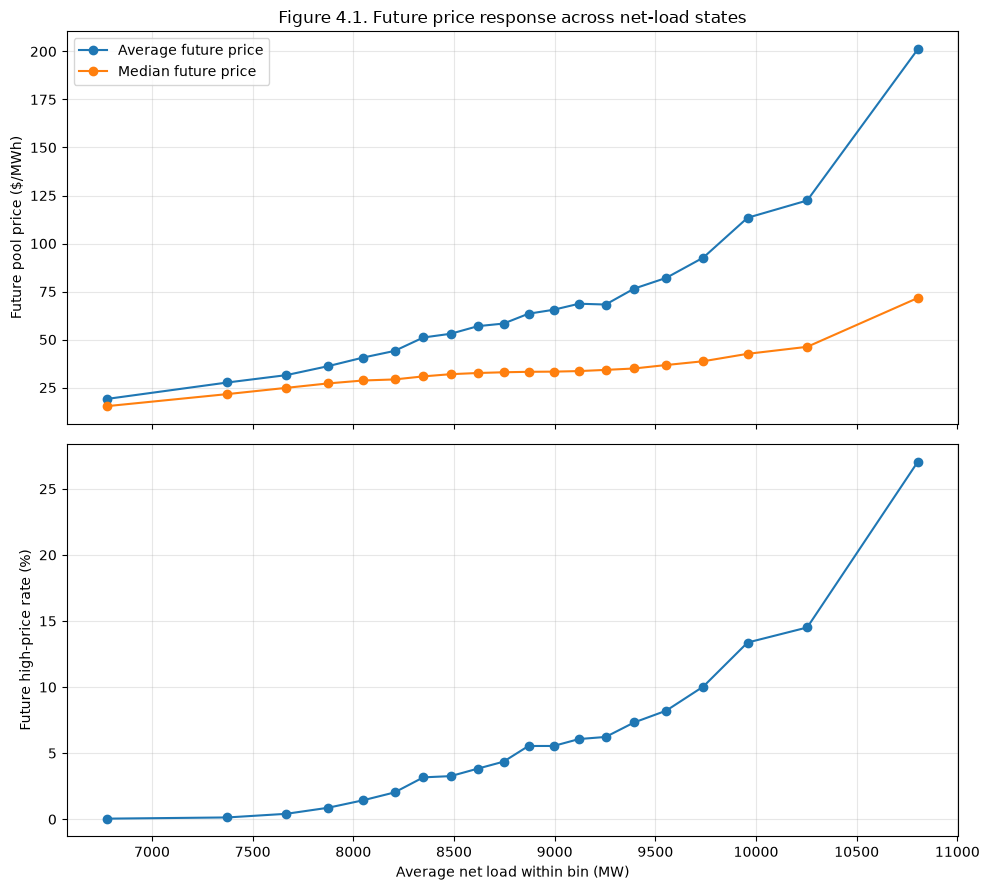

In [22]:
# ---------------------------------------------------------------------
# Examine nonlinear future-price response across net-load bins
# ---------------------------------------------------------------------

NET_LOAD_HORIZON = 1

net_load_threshold = future_response_by_bin(
    forecast_df,
    feature="net_load",
    horizon=NET_LOAD_HORIZON,
    q=20,
)

display(net_load_threshold.round(2))

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 9),
    sharex=True,
)

axes[0].plot(
    net_load_threshold["average_feature"],
    net_load_threshold["average_future_price"],
    marker="o",
    label="Average future price",
)

axes[0].plot(
    net_load_threshold["average_feature"],
    net_load_threshold["median_future_price"],
    marker="o",
    label="Median future price",
)

axes[0].set_title(
    "Figure 4.1. Future price response across net-load states"
)
axes[0].set_ylabel("Future pool price ($/MWh)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    net_load_threshold["average_feature"],
    net_load_threshold["future_high_price_rate_pct"],
    marker="o",
)

axes[1].set_xlabel("Average net load within bin (MW)")
axes[1].set_ylabel("Future high-price rate (%)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4.2. Gas Threshold

,observations,average_feature,median_future_price,average_future_price,p90_future_price,future_high_price_rate,future_high_price_rate_pct
feature_bin,,,,,,,
0,4584,0.19,31.13,58.18,72.45,0.05,4.58
1,4202,0.70,29.32,41.57,59.63,0.02,2.31
2,4440,1.07,25.61,41.83,53.74,0.03,3.00
3,4391,1.34,27.41,41.47,57.33,0.02,2.16
4,4799,1.61,30.99,42.63,57.64,0.02,1.98
5,3911,1.77,31.99,41.80,51.43,0.02,1.92
6,4728,1.89,31.75,43.06,51.83,0.02,1.97
7,4359,2.02,31.75,53.39,60.44,0.04,3.74
8,4296,2.17,27.52,50.87,59.80,0.04,3.86


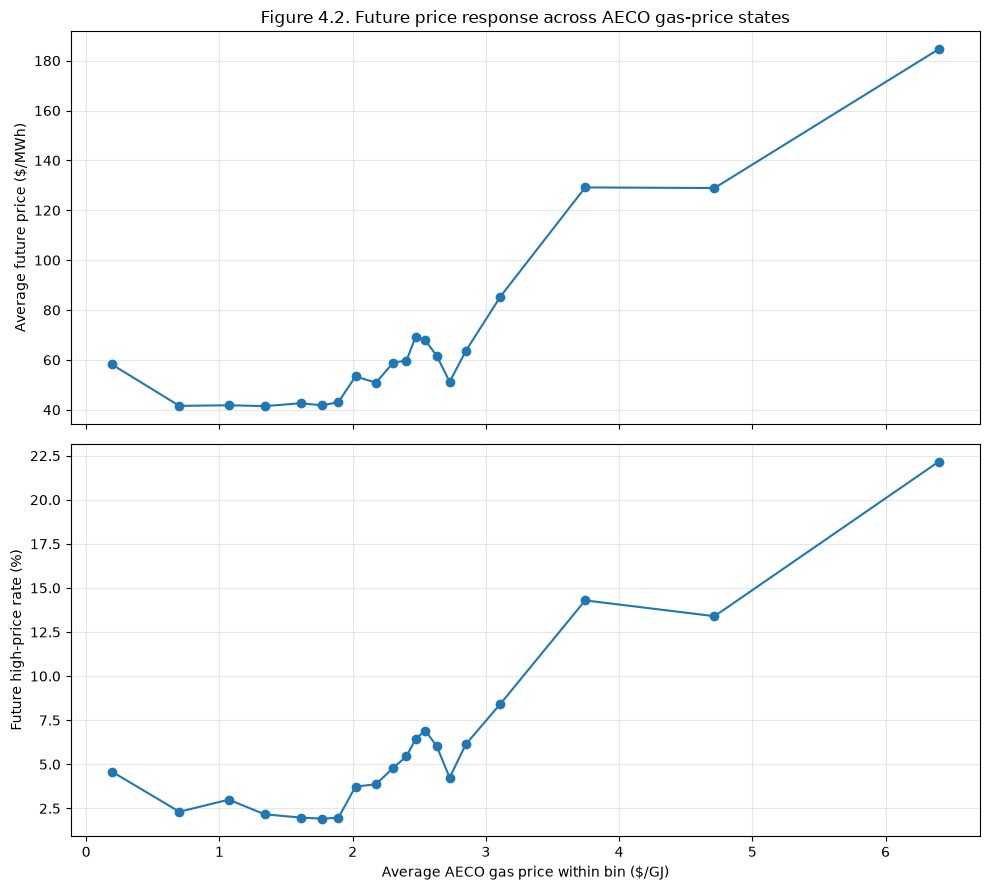

In [23]:
# ---------------------------------------------------------------------
# Examine nonlinear future-price response across AECO gas-price bins
# ---------------------------------------------------------------------

GAS_HORIZON = 1

gas_threshold = future_response_by_bin(
    forecast_df,
    feature="gas",
    horizon=GAS_HORIZON,
    q=20,
)

display(gas_threshold.round(2))

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 9),
    sharex=True,
)

axes[0].plot(
    gas_threshold["average_feature"],
    gas_threshold["average_future_price"],
    marker="o",
)

axes[0].set_title(
    "Figure 4.2. Future price response across AECO gas-price states"
)
axes[0].set_ylabel("Average future price ($/MWh)")
axes[0].grid(alpha=0.3)

axes[1].plot(
    gas_threshold["average_feature"],
    gas_threshold["future_high_price_rate_pct"],
    marker="o",
)

axes[1].set_xlabel("Average AECO gas price within bin ($/GJ)")
axes[1].set_ylabel("Future high-price rate (%)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4.3. Imports Theshold

,observations,average_feature,median_future_price,average_future_price,p90_future_price,future_high_price_rate,future_high_price_rate_pct
feature_bin,,,,,,,
0,22202,3.01,19.51,25.07,36.81,0.00,0.45
1,5054,48.16,28.46,35.43,51.77,0.01,0.97
2,3453,69.21,32.78,67.83,101.14,0.06,5.62
3,4470,95.79,32.96,52.99,78.38,0.03,3.45
4,5566,134.00,34.38,57.94,88.94,0.04,3.86
5,3156,166.09,41.44,67.42,110.10,0.05,5.10
6,4317,200.03,38.80,65.91,105.82,0.05,4.82
7,4505,242.88,38.38,66.33,105.09,0.05,5.31
8,4358,294.37,39.97,71.74,121.58,0.06,5.64


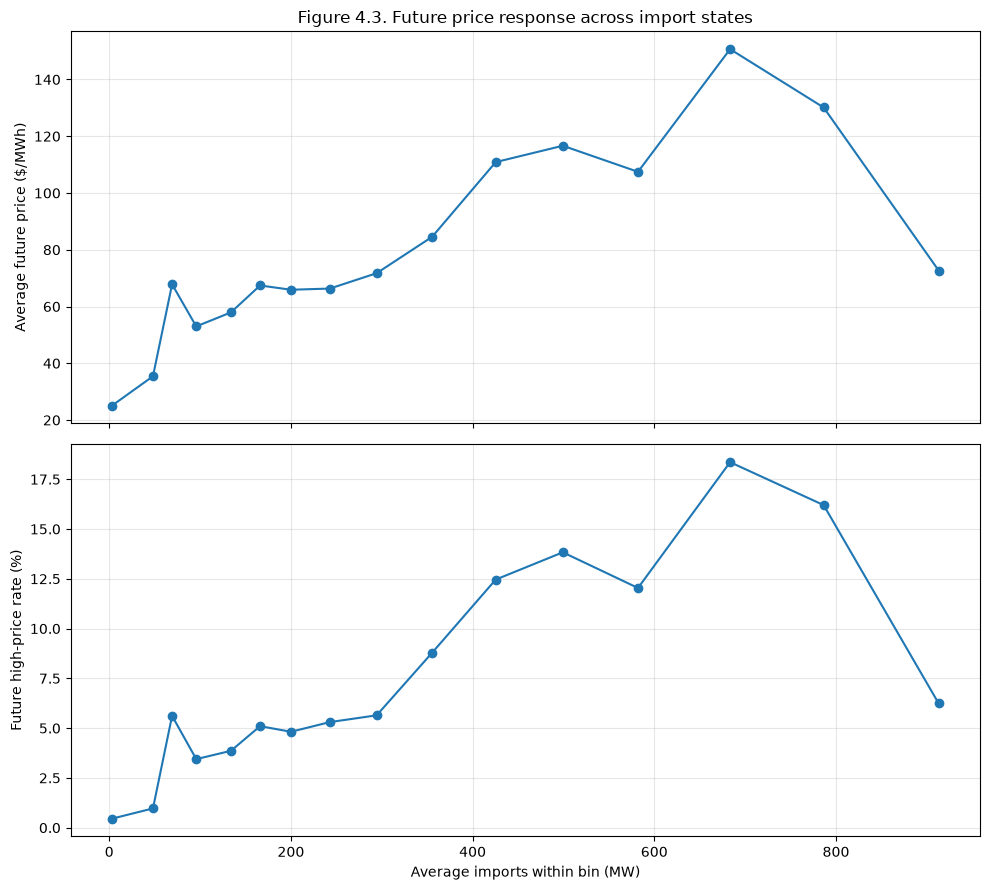

In [24]:
# ---------------------------------------------------------------------
# Examine nonlinear future-price response across import bins
# ---------------------------------------------------------------------

IMPORT_HORIZON = 1

imports_threshold = future_response_by_bin(
    forecast_df,
    feature="imports",
    horizon=IMPORT_HORIZON,
    q=20,
)

display(imports_threshold.round(2))

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 9),
    sharex=True,
)

axes[0].plot(
    imports_threshold["average_feature"],
    imports_threshold["average_future_price"],
    marker="o",
)

axes[0].set_title(
    "Figure 4.3. Future price response across import states"
)
axes[0].set_ylabel("Average future price ($/MWh)")
axes[0].grid(alpha=0.3)

axes[1].plot(
    imports_threshold["average_feature"],
    imports_threshold["future_high_price_rate_pct"],
    marker="o",
)

axes[1].set_xlabel("Average imports within bin (MW)")
axes[1].set_ylabel("Future high-price rate (%)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4.4. Wind Threshold

,observations,average_feature,median_future_price,average_future_price,p90_future_price,future_high_price_rate,future_high_price_rate_pct
feature_bin,,,,,,,
0,4384,16.68,36.40,107.79,270.19,0.12,11.95
1,4383,54.92,36.89,117.45,336.65,0.14,14.12
2,4383,96.47,36.06,106.66,280.81,0.12,12.16
3,4383,142.48,34.39,96.62,236.19,0.11,11.00
4,4383,193.40,34.39,94.89,217.82,0.11,10.56
5,4383,248.57,33.52,84.06,173.45,0.09,9.06
6,4384,309.66,33.25,82.77,174.95,0.09,8.92
7,4383,377.00,33.11,75.47,144.72,0.08,8.01
8,4383,452.25,32.94,72.00,137.85,0.08,7.57


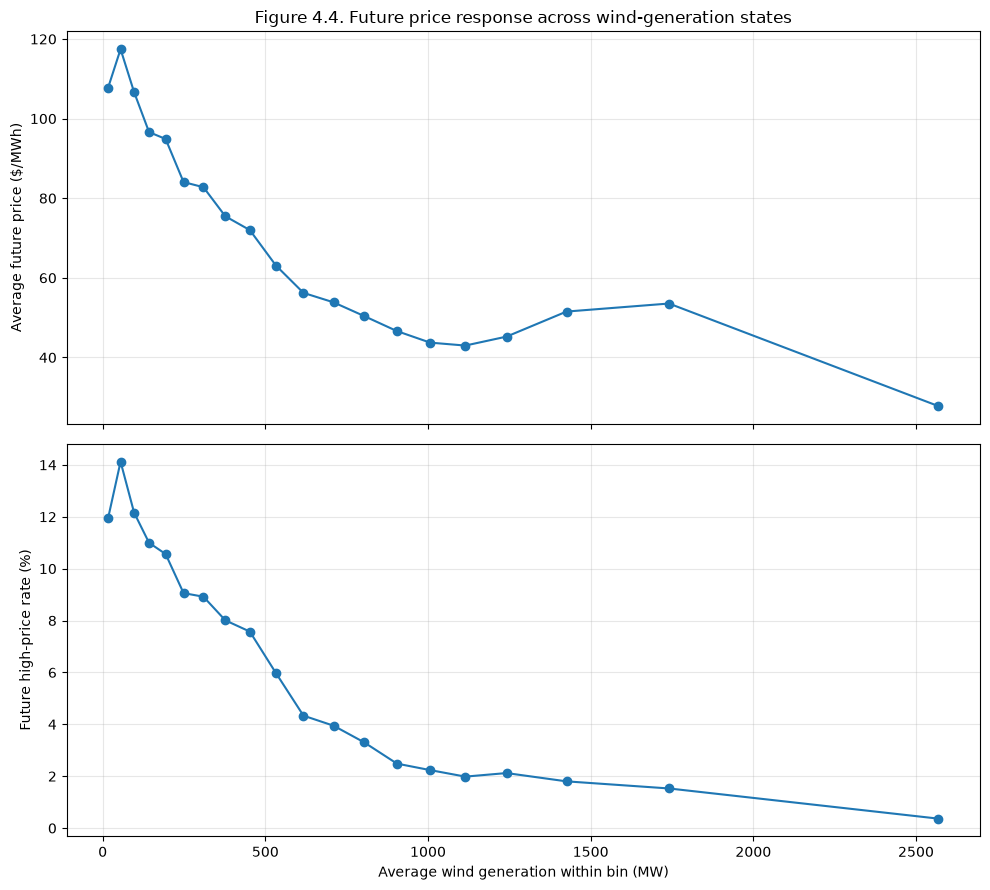

In [25]:
# ---------------------------------------------------------------------
# Examine nonlinear future-price response across wind-generation bins
# ---------------------------------------------------------------------

WIND_HORIZON = 1

wind_threshold = future_response_by_bin(
    forecast_df,
    feature="wind",
    horizon=WIND_HORIZON,
    q=20,
)

display(wind_threshold.round(2))

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 9),
    sharex=True,
)

axes[0].plot(
    wind_threshold["average_feature"],
    wind_threshold["average_future_price"],
    marker="o",
)

axes[0].set_title(
    "Figure 4.4. Future price response across wind-generation states"
)
axes[0].set_ylabel("Average future price ($/MWh)")
axes[0].grid(alpha=0.3)

axes[1].plot(
    wind_threshold["average_feature"],
    wind_threshold["future_high_price_rate_pct"],
    marker="o",
)

axes[1].set_xlabel("Average wind generation within bin (MW)")
axes[1].set_ylabel("Future high-price rate (%)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4.5. Outage Threshold

,observations,average_feature,median_future_price,average_future_price,p90_future_price,future_high_price_rate,future_high_price_rate_pct
feature_bin,,,,,,,
0,4385,2238.82,30.76,44.20,70.86,0.02,2.17
1,4391,2500.08,33.22,47.56,74.00,0.03,2.64
2,4379,2669.50,32.71,51.96,75.79,0.03,3.11
3,4379,2803.25,31.67,46.90,71.23,0.03,2.74
4,4385,2926.21,31.74,54.26,78.05,0.04,3.90
5,4383,3034.21,31.97,56.63,87.86,0.04,4.36
6,4388,3131.93,32.20,56.45,89.72,0.04,4.19
7,4389,3223.43,31.95,58.97,94.47,0.05,4.83
8,4372,3312.94,32.79,63.63,98.88,0.05,5.22


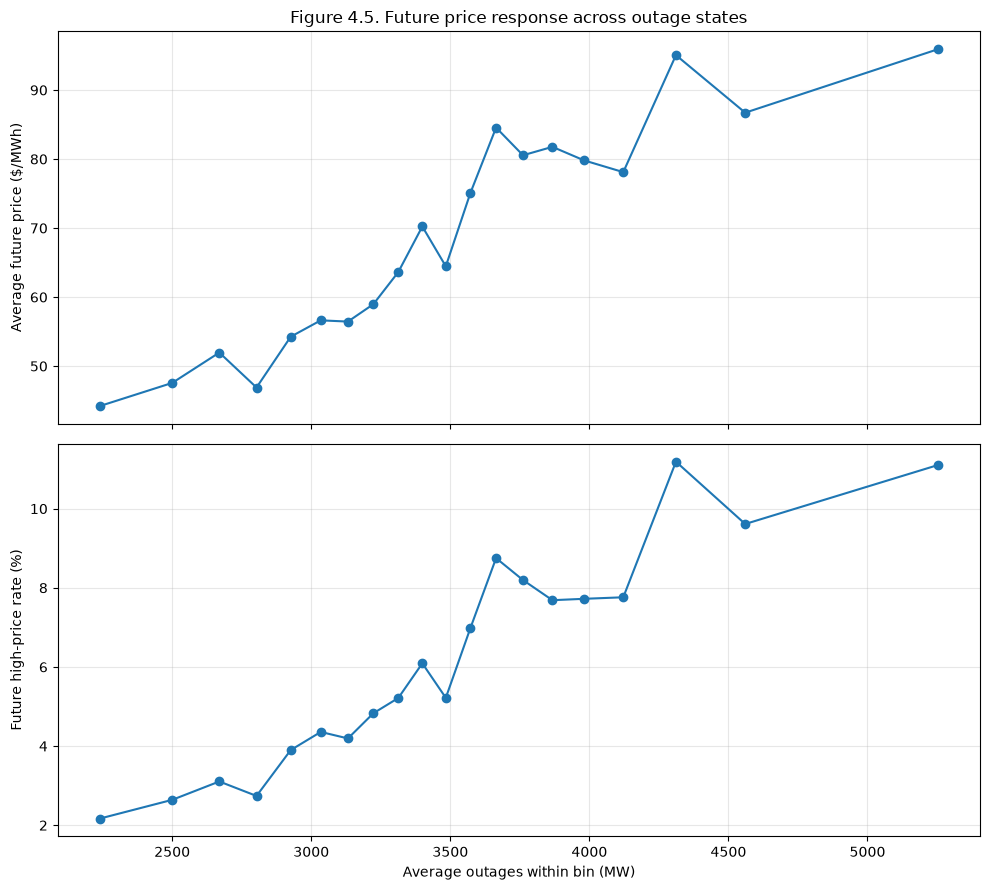

In [26]:
# ---------------------------------------------------------------------
# Examine nonlinear future-price response across outage bins
# ---------------------------------------------------------------------

OUTAGE_HORIZON = 1

outage_threshold = future_response_by_bin(
    forecast_df,
    feature="outages",
    horizon=OUTAGE_HORIZON,
    q=20,
)

display(outage_threshold.round(2))

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 9),
    sharex=True,
)

axes[0].plot(
    outage_threshold["average_feature"],
    outage_threshold["average_future_price"],
    marker="o",
)

axes[0].set_title(
    "Figure 4.5. Future price response across outage states"
)
axes[0].set_ylabel("Average future price ($/MWh)")
axes[0].grid(alpha=0.3)

axes[1].plot(
    outage_threshold["average_feature"],
    outage_threshold["future_high_price_rate_pct"],
    marker="o",
)

axes[1].set_xlabel("Average outages within bin (MW)")
axes[1].set_ylabel("Future high-price rate (%)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4.6. Candidate Threshold Table

In [27]:
# ---------------------------------------------------------------------
# Identify candidate nonlinear threshold regions
# ---------------------------------------------------------------------

threshold_results = {
    "net_load": net_load_threshold,
    "gas": gas_threshold,
    "imports": imports_threshold,
    "wind": wind_threshold,
    "outages": outage_threshold,
}

base_high_price_rate = (
    forecast_df["high_price_t1"].mean()
)

candidate_thresholds = []

for variable, summary in threshold_results.items():

    # For inverse variables such as wind, the relevant threshold may
    # occur in the lower tail. We report both the minimum-risk and
    # maximum-risk operating states.
    highest_risk_bin = (
        summary
        .sort_values(
            "future_high_price_rate",
            ascending=False,
        )
        .iloc[0]
    )

    lowest_risk_bin = (
        summary
        .sort_values(
            "future_high_price_rate",
            ascending=True,
        )
        .iloc[0]
    )

    elevated = summary.loc[
        summary["future_high_price_rate"]
        .ge(2 * base_high_price_rate)
    ]

    first_elevated_feature = (
        elevated["average_feature"].iloc[0]
        if not elevated.empty
        else np.nan
    )

    candidate_thresholds.append({
        "variable": variable,
        "base_rate_pct": base_high_price_rate * 100,
        "first_bin_above_2x_base": first_elevated_feature,
        "highest_risk_feature_state": (
            highest_risk_bin["average_feature"]
        ),
        "highest_future_high_price_rate_pct": (
            highest_risk_bin[
                "future_high_price_rate_pct"
            ]
        ),
        "lowest_risk_feature_state": (
            lowest_risk_bin["average_feature"]
        ),
        "lowest_future_high_price_rate_pct": (
            lowest_risk_bin[
                "future_high_price_rate_pct"
            ]
        ),
    })

candidate_thresholds = pd.DataFrame(
    candidate_thresholds
)

display(candidate_thresholds.round(2))

,variable,base_rate_pct,first_bin_above_2x_base,highest_risk_feature_state,highest_future_high_price_rate_pct,lowest_risk_feature_state,lowest_future_high_price_rate_pct
0,net_load,6.17,9957.98,10803.77,27.05,6777.33,0.05
1,gas,6.17,3.75,6.40,22.16,1.77,1.92
2,imports,6.17,425.46,683.44,18.36,3.01,0.45
3,wind,6.17,54.92,54.92,14.12,2569.15,0.36
4,outages,6.17,NaN,4311.32,11.19,2238.82,2.17


## Nonlinear Threshold Summary

The threshold table identifies operating regions in which future high-price risk rises materially above its unconditional base rate. These values should be treated as candidate breakpoints rather than fixed economic thresholds. Quantile boundaries depend on the sample period and may move as Alberta's load, generation fleet, renewable capacity, and market rules change.

Later models should compare raw continuous variables with threshold flags, splines, and tree-based representations rather than assuming a single linear marginal effect.

## 5. Interaction Discovery

### 5.1. Reusable Interaction Heatmap Function

In [28]:
# ---------------------------------------------------------------------
# Define quantile interaction analysis
# ---------------------------------------------------------------------

def interaction_summary(
    data,
    feature_x,
    feature_y,
    horizon=1,
    q=5,
):
    sample = data[
        [
            feature_x,
            feature_y,
            f"price_t{horizon}",
            f"high_price_t{horizon}",
        ]
    ].dropna().copy()

    sample["x_bin"] = pd.qcut(
        sample[feature_x],
        q=q,
        labels=False,
        duplicates="drop",
    )

    sample["y_bin"] = pd.qcut(
        sample[feature_y],
        q=q,
        labels=False,
        duplicates="drop",
    )

    price_matrix = (
        sample
        .groupby(
            [
                "y_bin",
                "x_bin",
            ]
        )[f"price_t{horizon}"]
        .mean()
        .unstack()
    )

    high_price_matrix = (
        sample
        .groupby(
            [
                "y_bin",
                "x_bin",
            ]
        )[f"high_price_t{horizon}"]
        .mean()
        .unstack()
        .mul(100)
    )

    count_matrix = (
        sample
        .groupby(
            [
                "y_bin",
                "x_bin",
            ]
        )
        .size()
        .unstack()
    )

    return {
        "sample": sample,
        "price_matrix": price_matrix,
        "high_price_matrix": high_price_matrix,
        "count_matrix": count_matrix,
    }


def plot_interaction_heatmaps(
    interaction,
    feature_x_label,
    feature_y_label,
    figure_title,
):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(13, 5),
    )

    price_image = axes[0].imshow(
        interaction["price_matrix"],
        aspect="auto",
        origin="lower",
    )

    axes[0].set_title("Average future price")
    axes[0].set_xlabel(
        f"{feature_x_label} quantile"
    )
    axes[0].set_ylabel(
        f"{feature_y_label} quantile"
    )

    plt.colorbar(
        price_image,
        ax=axes[0],
        label="$/MWh",
    )

    event_image = axes[1].imshow(
        interaction["high_price_matrix"],
        aspect="auto",
        origin="lower",
    )

    axes[1].set_title("Future high-price rate")
    axes[1].set_xlabel(
        f"{feature_x_label} quantile"
    )
    axes[1].set_ylabel(
        f"{feature_y_label} quantile"
    )

    plt.colorbar(
        event_image,
        ax=axes[1],
        label="Percent",
    )

    fig.suptitle(
        figure_title,
        y=1.02,
    )

    plt.tight_layout()
    plt.show()

### 5.5. Net Load x Gas

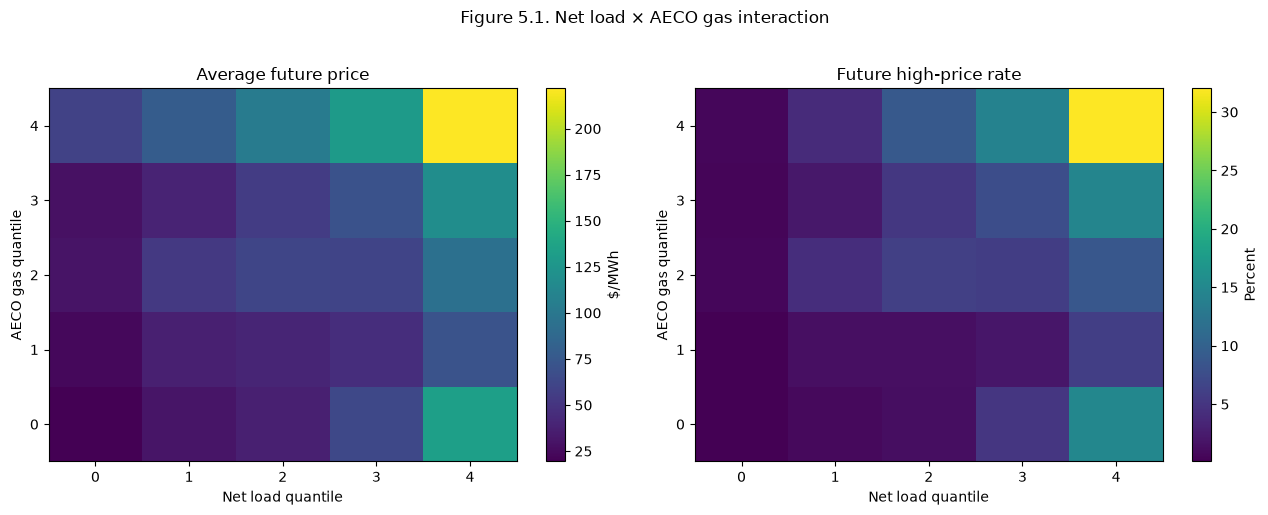

In [29]:
# ---------------------------------------------------------------------
# Examine interaction between net load and AECO gas price
# ---------------------------------------------------------------------

net_load_gas_interaction = interaction_summary(
    forecast_df,
    feature_x="net_load",
    feature_y="gas",
    horizon=1,
    q=5,
)

plot_interaction_heatmaps(
    net_load_gas_interaction,
    feature_x_label="Net load",
    feature_y_label="AECO gas",
    figure_title=(
        "Figure 5.1. Net load × AECO gas interaction"
    ),
)

### 5.2. Net Load x Wind

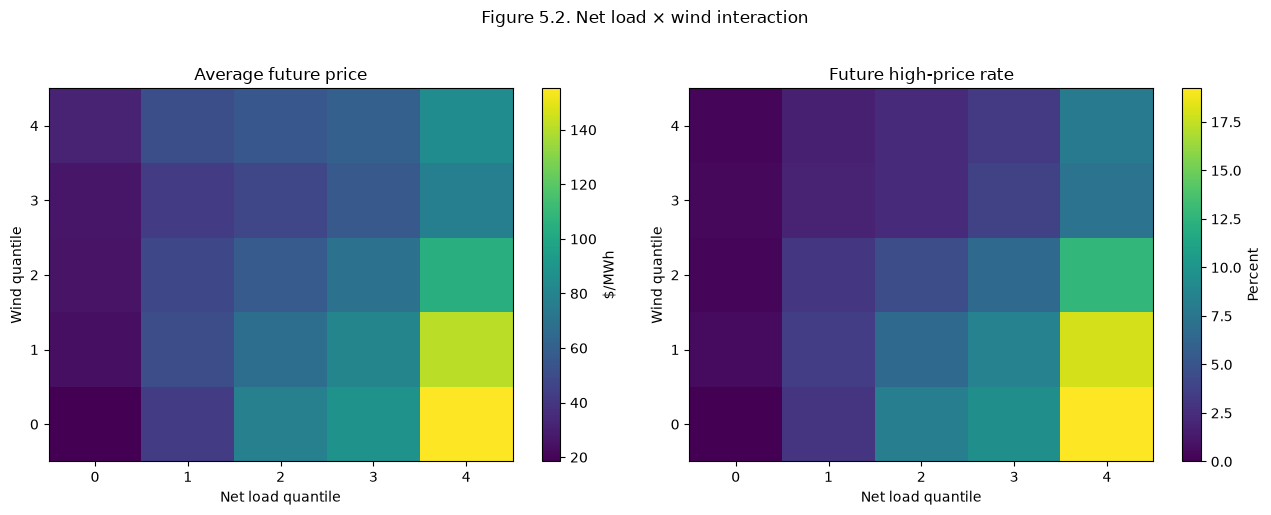

In [30]:
# ---------------------------------------------------------------------
# Examine interaction between net load and wind generation
# ---------------------------------------------------------------------

net_load_wind_interaction = interaction_summary(
    forecast_df,
    feature_x="net_load",
    feature_y="wind",
    horizon=1,
    q=5,
)

plot_interaction_heatmaps(
    net_load_wind_interaction,
    feature_x_label="Net load",
    feature_y_label="Wind",
    figure_title=(
        "Figure 5.2. Net load × wind interaction"
    ),
)

### 5.3. Net Load x Imports

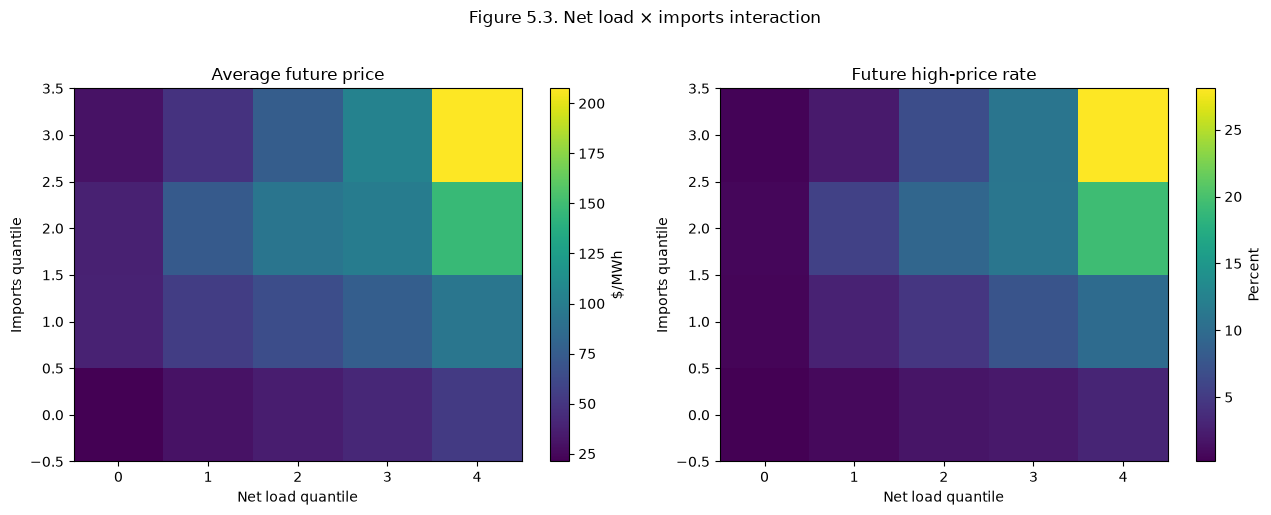

In [31]:
# ---------------------------------------------------------------------
# Examine interaction between net load and imports
# ---------------------------------------------------------------------

net_load_imports_interaction = interaction_summary(
    forecast_df,
    feature_x="net_load",
    feature_y="imports",
    horizon=1,
    q=5,
)

plot_interaction_heatmaps(
    net_load_imports_interaction,
    feature_x_label="Net load",
    feature_y_label="Imports",
    figure_title=(
        "Figure 5.3. Net load × imports interaction"
    ),
)

### 5.4. Net Load x Outages

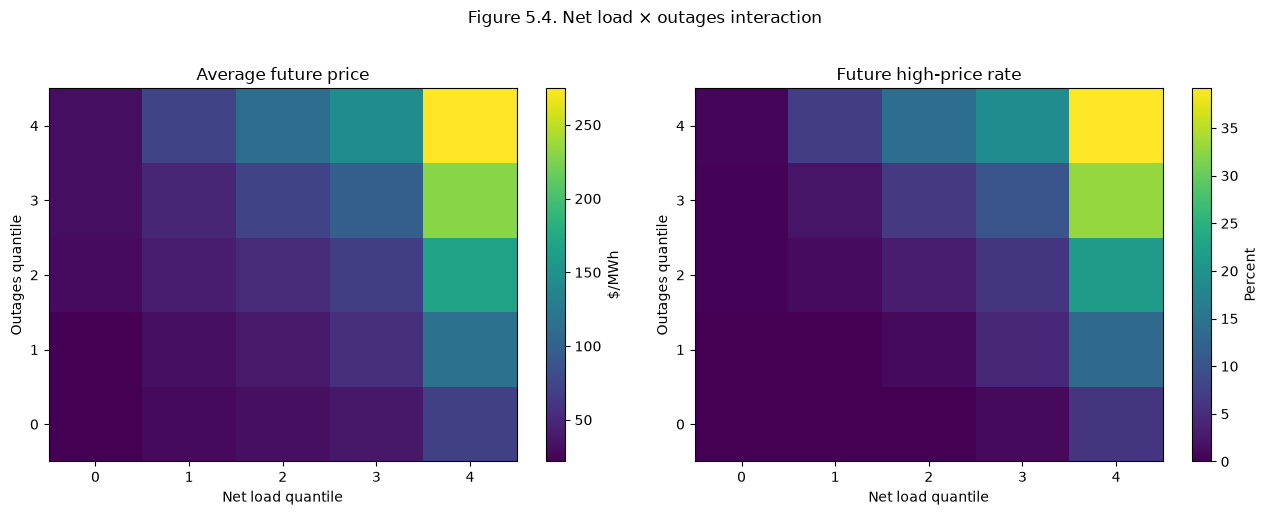

In [32]:
# ---------------------------------------------------------------------
# Examine interaction between net load and outages
# ---------------------------------------------------------------------

net_load_outages_interaction = interaction_summary(
    forecast_df,
    feature_x="net_load",
    feature_y="outages",
    horizon=1,
    q=5,
)

plot_interaction_heatmaps(
    net_load_outages_interaction,
    feature_x_label="Net load",
    feature_y_label="Outages",
    figure_title=(
        "Figure 5.4. Net load × outages interaction"
    ),
)

### 5.5. Wind x Hour

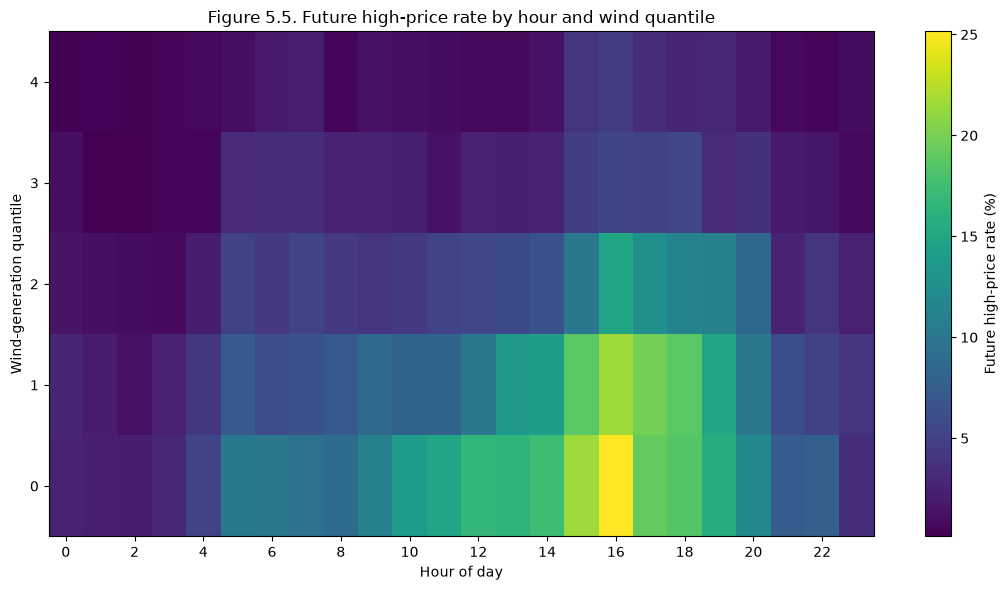

In [33]:
# ---------------------------------------------------------------------
# Examine how wind value changes across the day
# ---------------------------------------------------------------------

wind_hour_sample = forecast_df[
    [
        "wind",
        "hour_alberta",
        "price_t1",
        "high_price_t1",
    ]
].dropna().copy()

wind_hour_sample["wind_bin"] = pd.qcut(
    wind_hour_sample["wind"],
    q=5,
    labels=False,
    duplicates="drop",
)

wind_hour_high_price = (
    wind_hour_sample
    .groupby(
        [
            "hour_alberta",
            "wind_bin",
        ]
    )["high_price_t1"]
    .mean()
    .unstack()
    .mul(100)
)

fig, ax = plt.subplots(figsize=(11, 6))

image = ax.imshow(
    wind_hour_high_price.T,
    aspect="auto",
    origin="lower",
)

ax.set_title(
    "Figure 5.5. Future high-price rate by hour and wind quantile"
)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Wind-generation quantile")
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels(range(0, 24, 2))

plt.colorbar(
    image,
    ax=ax,
    label="Future high-price rate (%)",
)

plt.tight_layout()
plt.show()

### 5.6. Wind x Season

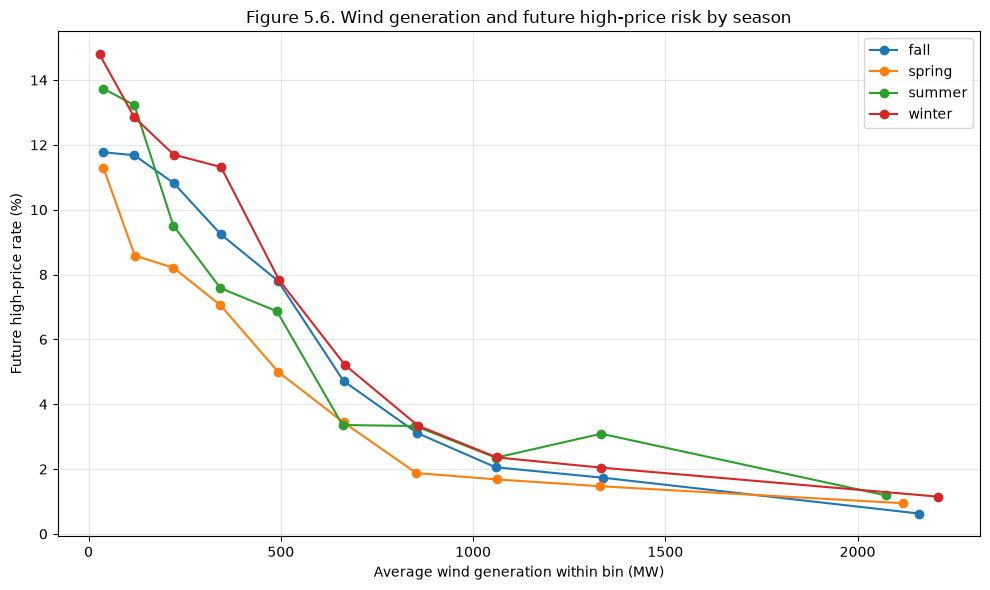

In [34]:
# ---------------------------------------------------------------------
# Examine how wind value changes across seasons
# ---------------------------------------------------------------------

wind_season_sample = forecast_df[
    [
        "wind",
        "season",
        "price_t1",
        "high_price_t1",
    ]
].dropna().copy()

wind_season_sample["wind_bin"] = pd.qcut(
    wind_season_sample["wind"],
    q=10,
    labels=False,
    duplicates="drop",
)

wind_season_summary = (
    wind_season_sample
    .groupby(
        [
            "season",
            "wind_bin",
        ]
    )
    .agg(
        average_wind=(
            "wind",
            "mean",
        ),
        future_high_price_rate=(
            "high_price_t1",
            "mean",
        ),
        average_future_price=(
            "price_t1",
            "mean",
        ),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

for season, group in wind_season_summary.groupby("season"):

    ax.plot(
        group["average_wind"],
        group["future_high_price_rate"] * 100,
        marker="o",
        label=season,
    )

ax.set_title(
    "Figure 5.6. Wind generation and future high-price risk by season"
)
ax.set_xlabel("Average wind generation within bin (MW)")
ax.set_ylabel("Future high-price rate (%)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.7. Temperature x Load

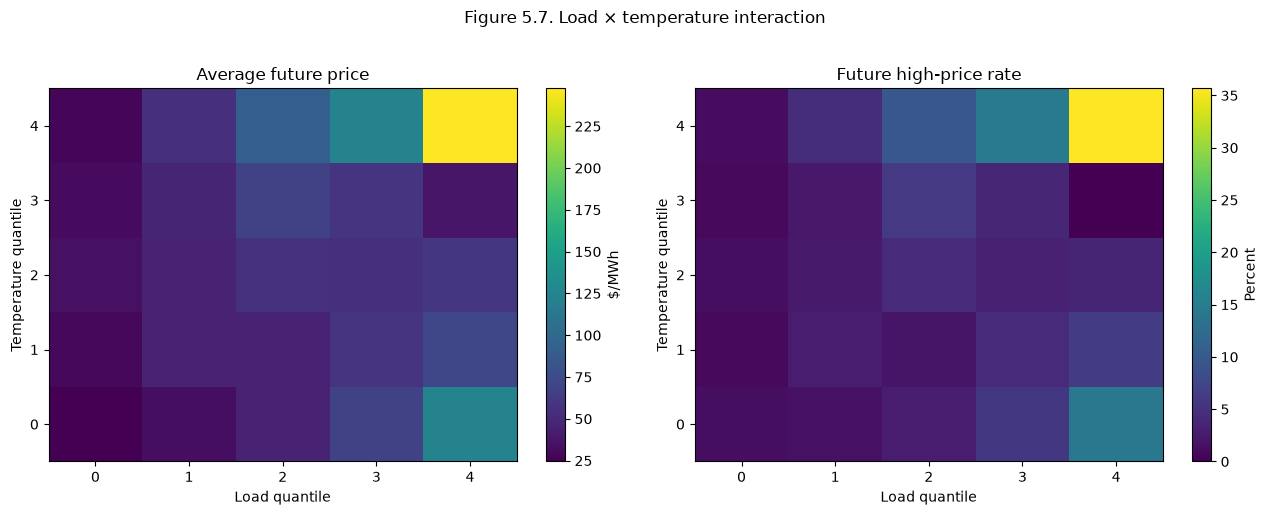

In [35]:
# ---------------------------------------------------------------------
# Examine interaction between temperature and load
# ---------------------------------------------------------------------

if "temperature" in forecast_df.columns:

    temperature_load_interaction = interaction_summary(
        forecast_df,
        feature_x="load",
        feature_y="temperature",
        horizon=1,
        q=5,
    )

    plot_interaction_heatmaps(
        temperature_load_interaction,
        feature_x_label="Load",
        feature_y_label="Temperature",
        figure_title=(
            "Figure 5.7. Load × temperature interaction"
        ),
    )

else:
    print(
        "Temperature interaction skipped because the configured "
        "load-weighted temperature column was not found."
    )

### 5.8. Gas x Outages

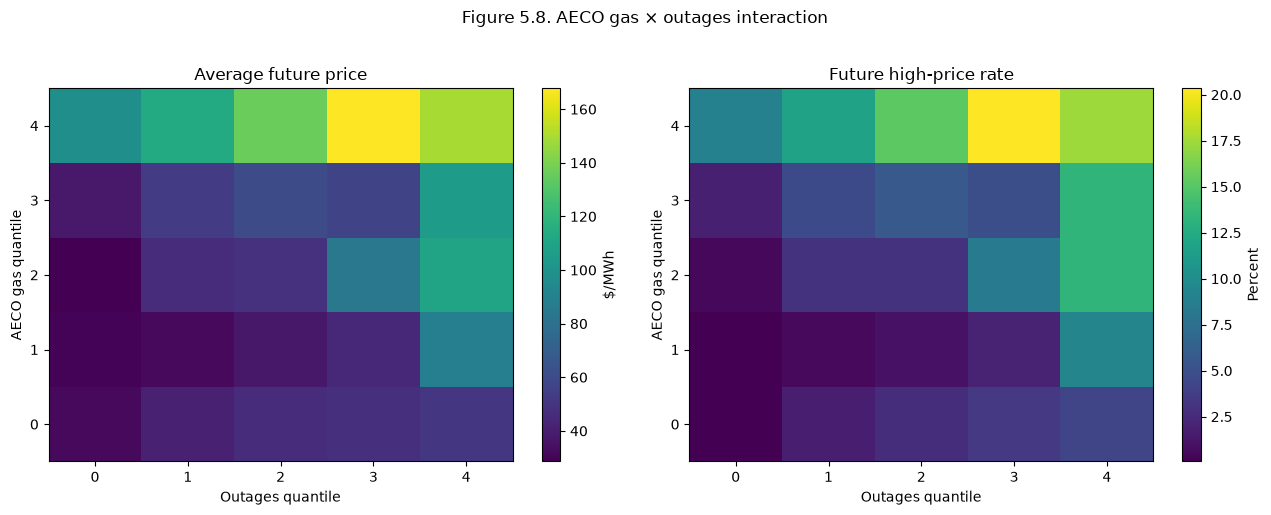

In [36]:
# ---------------------------------------------------------------------
# Examine interaction between gas price and outages
# ---------------------------------------------------------------------

gas_outages_interaction = interaction_summary(
    forecast_df,
    feature_x="outages",
    feature_y="gas",
    horizon=1,
    q=5,
)

plot_interaction_heatmaps(
    gas_outages_interaction,
    feature_x_label="Outages",
    feature_y_label="AECO gas",
    figure_title=(
        "Figure 5.8. AECO gas × outages interaction"
    ),
)

### 5.9. Candidate Interaction Ranking

In [37]:
# ---------------------------------------------------------------------
# Rank candidate interactions by variation in conditional risk
# ---------------------------------------------------------------------

interaction_candidates = {
    "net_load_x_gas": net_load_gas_interaction,
    "net_load_x_wind": net_load_wind_interaction,
    "net_load_x_imports": net_load_imports_interaction,
    "net_load_x_outages": net_load_outages_interaction,
    "gas_x_outages": gas_outages_interaction,
}

interaction_ranking = []

for name, result in interaction_candidates.items():

    risk_values = (
        result["high_price_matrix"]
        .stack()
        .dropna()
    )

    price_values = (
        result["price_matrix"]
        .stack()
        .dropna()
    )

    interaction_ranking.append({
        "interaction": name,
        "risk_range_percentage_points": (
            risk_values.max()
            - risk_values.min()
        ),
        "risk_standard_deviation": (
            risk_values.std()
        ),
        "average_price_range": (
            price_values.max()
            - price_values.min()
        ),
        "minimum_cell_observations": (
            result["count_matrix"]
            .stack()
            .min()
        ),
    })

interaction_ranking = (
    pd.DataFrame(interaction_ranking)
    .sort_values(
        "risk_range_percentage_points",
        ascending=False,
    )
)

display(interaction_ranking.round(2))

,interaction,risk_range_percentage_points,risk_standard_deviation,average_price_range,minimum_cell_observations
3,net_load_x_outages,39.16,10.58,253.01,1033
0,net_load_x_gas,31.93,7.09,202.50,1950
2,net_load_x_imports,27.90,7.12,186.39,2126
4,gas_x_outages,20.28,5.88,139.19,1610
1,net_load_x_wind,19.23,5.21,136.79,403


## Interaction Summary

Large variation across an interaction grid indicates that the relationship between one variable and future prices depends on the state of another variable. It does not prove that an explicit multiplicative term will improve forecasting performance.

The most credible interactions should satisfy three conditions:

- they have a plausible market mechanism;
- they contain sufficient observations across cells;
- they remain visible under time-based or regime-specific validation.

Tree-based models can learn many nonlinear interactions automatically, while linear and logistic models require explicit interaction terms or transformed variables.

## 7. Candidate System-Margin Variables

### 7.1. Why Capacity Is Not Enough

Reported maximum capacity measures the nominal size of the generation fleet, not the amount of supply that is dispatchable, available, deliverable, or producing during a stressed hour.

A more useful forecasting concept is system margin: the amount of available or potentially available supply remaining after accounting for the demand that must be served. Depending on the definition, a margin measure can incorporate gross load, net load, observed generation availability, outages, imports, renewable output, or intertie capability.

No single margin constructed here should be interpreted as an official operating-reserve measure. The variables are analytical proxies intended to test whether relative system tightness is more informative than load or nameplate capacity alone.

### 7.2. Build Candidate Margin Variables

In [38]:
# ---------------------------------------------------------------------
# Build analysis-only candidate system-margin variables
# ---------------------------------------------------------------------

margin_df = pd.DataFrame({
    "timestamp_utc": forecast_df["timestamp_utc"],
    "load": forecast_df["load"],
    "net_load": forecast_df["net_load"],
    "imports": forecast_df["imports"],
    "outages": forecast_df["outages"],
})

# Reported maximum-capacity margin.
if "total_maximum_capacity" in master.columns:

    margin_df["maximum_capacity_margin"] = (
        master["total_maximum_capacity"]
        - forecast_df["net_load"]
    )

    margin_df["maximum_capacity_margin_pct"] = (
        margin_df["maximum_capacity_margin"]
        / forecast_df["net_load"]
        * 100
    )

# Reported available-supply margin.
if "total_system_available" in master.columns:

    margin_df["available_supply_margin"] = (
        master["total_system_available"]
        - forecast_df["net_load"]
    )

    margin_df["available_supply_margin_pct"] = (
        margin_df["available_supply_margin"]
        / forecast_df["net_load"]
        * 100
    )

# Import-assisted versions.
if "maximum_capacity_margin" in margin_df.columns:

    margin_df["maximum_capacity_import_assisted_margin"] = (
        margin_df["maximum_capacity_margin"]
        + forecast_df["imports"]
    )

if "available_supply_margin" in margin_df.columns:

    margin_df["available_import_assisted_margin"] = (
        margin_df["available_supply_margin"]
        + forecast_df["imports"]
    )

# Outage-adjusted nameplate proxy.
if "total_maximum_capacity" in master.columns:

    margin_df["outage_adjusted_capacity"] = (
        master["total_maximum_capacity"]
        - forecast_df["outages"]
    )

    margin_df["outage_adjusted_margin"] = (
        margin_df["outage_adjusted_capacity"]
        - forecast_df["net_load"]
    )

    margin_df["outage_adjusted_import_assisted_margin"] = (
        margin_df["outage_adjusted_margin"]
        + forecast_df["imports"]
    )

margin_feature_names = [
    column
    for column in margin_df.columns
    if column not in [
        "timestamp_utc",
        "load",
        "net_load",
        "imports",
        "outages",
    ]
]

if not margin_feature_names:
    raise KeyError(
        "No candidate margin variables could be created. "
        "Check whether total_maximum_capacity or "
        "total_system_available exists in master."
    )

display(
    margin_df[
        margin_feature_names
    ]
    .describe()
    .T
    .round(2)
)

,count,mean,std,min,25%,50%,75%,max
maximum_capacity_margin,87665.0,8415.13,2136.49,4641.71,7048.89,7856.34,8920.34,16827.54
maximum_capacity_margin_pct,87665.0,98.68,35.03,40.32,75.44,90.82,111.34,300.96
available_supply_margin,87665.0,4123.72,1928.18,-168.35,2863.67,3661.45,4760.07,12657.15
available_supply_margin_pct,87665.0,48.97,27.58,-1.57,30.74,42.08,58.44,194.82
maximum_capacity_import_assisted_margin,87665.0,8689.40,2088.94,4795.06,7309.89,8165.69,9262.29,16852.54
available_import_assisted_margin,87665.0,4397.99,1869.44,552.54,3123.44,3947.48,5059.09,12657.15
outage_adjusted_capacity,87665.0,13728.61,1479.16,10166.70,12816.70,13340.70,14059.60,20146.60
outage_adjusted_margin,87665.0,4924.45,1816.14,986.75,3733.34,4494.29,5521.94,13283.75
outage_adjusted_import_assisted_margin,87665.0,5198.72,1757.50,1856.75,3992.94,4777.23,5827.32,13283.75


### 7.3. Compare Margins Against Future Price

In [39]:
# ---------------------------------------------------------------------
# Compare candidate margin variables with future pool price
# ---------------------------------------------------------------------

margin_price_results = []

for feature in margin_feature_names:

    for horizon in forecast_horizons:

        sample = pd.DataFrame({
            "margin": margin_df[feature],
            "future_price": forecast_df[
                f"price_t{horizon}"
            ],
        }).dropna()

        margin_price_results.append({
            "feature": feature,
            "horizon_hours": horizon,
            "observations": len(sample),
            "pearson": (
                sample["margin"]
                .corr(
                    sample["future_price"],
                    method="pearson",
                )
            ),
            "spearman": (
                sample["margin"]
                .corr(
                    sample["future_price"],
                    method="spearman",
                )
            ),
        })

margin_price_results = pd.DataFrame(
    margin_price_results
)

display(
    margin_price_results
    .assign(
        absolute_spearman=lambda frame: (
            frame["spearman"].abs()
        )
    )
    .sort_values(
        "absolute_spearman",
        ascending=False,
    )
    .drop(
        columns="absolute_spearman"
    )
    .head(30)
    .round(3)
)

,feature,horizon_hours,observations,pearson,spearman
5,maximum_capacity_margin_pct,1,87664,-0.133,-0.206
15,available_supply_margin_pct,1,87664,-0.131,-0.191
33,outage_adjusted_capacity,12,87653,0.074,0.178
34,outage_adjusted_capacity,24,87641,0.074,0.175
32,outage_adjusted_capacity,6,87659,0.065,0.170
31,outage_adjusted_capacity,3,87662,0.061,0.164
6,maximum_capacity_margin_pct,3,87662,-0.101,-0.160
30,outage_adjusted_capacity,1,87664,0.058,0.157
35,outage_adjusted_margin,1,87664,-0.113,-0.153
23,maximum_capacity_import_assisted_margin,12,87653,0.070,0.149


### 7.4. Compare Margins Against Future High-Price Probability

In [40]:
# ---------------------------------------------------------------------
# Compare candidate margins with future high-price events
# ---------------------------------------------------------------------

margin_event_results = []

for feature in margin_feature_names:

    for horizon in forecast_horizons:

        sample = pd.DataFrame({
            "margin": margin_df[feature],
            "future_high_price": forecast_df[
                f"high_price_t{horizon}"
            ],
        }).dropna()

        margin_event_results.append({
            "feature": feature,
            "horizon_hours": horizon,
            "observations": len(sample),
            "oriented_auc": oriented_auc(
                sample["future_high_price"],
                sample["margin"],
            ),
        })

margin_event_results = pd.DataFrame(
    margin_event_results
)

display(
    margin_event_results
    .sort_values(
        "oriented_auc",
        ascending=False,
    )
    .head(30)
    .round(3)
)

,feature,horizon_hours,observations,oriented_auc
23,maximum_capacity_import_assisted_margin,12,87653,0.642
33,outage_adjusted_capacity,12,87653,0.629
34,outage_adjusted_capacity,24,87641,0.626
28,available_import_assisted_margin,12,87653,0.625
3,maximum_capacity_margin,12,87653,0.620
32,outage_adjusted_capacity,6,87659,0.620
31,outage_adjusted_capacity,3,87662,0.614
5,maximum_capacity_margin_pct,1,87664,0.610
30,outage_adjusted_capacity,1,87664,0.610
43,outage_adjusted_import_assisted_margin,12,87653,0.610


### 7.5. Margin Ranking Against Load and Net Load

In [41]:
# ---------------------------------------------------------------------
# Compare system margins with gross load and net load
# ---------------------------------------------------------------------

margin_comparison_data = pd.concat(
    [
        forecast_df[
            [
                "load",
                "net_load",
                "price_t1",
                "high_price_t1",
            ]
        ],
        margin_df[
            margin_feature_names
        ],
    ],
    axis=1,
)

comparison_features = [
    "load",
    "net_load",
    *margin_feature_names,
]

margin_ranking = []

for feature in comparison_features:

    sample = margin_comparison_data[
        [
            feature,
            "price_t1",
            "high_price_t1",
        ]
    ].dropna()

    margin_ranking.append({
        "feature": feature,
        "observations": len(sample),
        "spearman_future_price": (
            sample[feature]
            .corr(
                sample["price_t1"],
                method="spearman",
            )
        ),
        "oriented_auc": oriented_auc(
            sample["high_price_t1"],
            sample[feature],
        ),
    })

margin_ranking = (
    pd.DataFrame(margin_ranking)
    .sort_values(
        "oriented_auc",
        ascending=False,
    )
)

display(margin_ranking.round(3))

,feature,observations,spearman_future_price,oriented_auc
1,net_load,87664,0.418,0.768
0,load,87664,0.432,0.728
3,maximum_capacity_margin_pct,87664,-0.206,0.610
8,outage_adjusted_capacity,87664,0.157,0.610
5,available_supply_margin_pct,87664,-0.191,0.601
9,outage_adjusted_margin,87664,-0.153,0.577
4,available_supply_margin,87664,-0.131,0.547
10,outage_adjusted_import_assisted_margin,87664,-0.063,0.536
6,maximum_capacity_import_assisted_margin,87664,-0.014,0.523
2,maximum_capacity_margin,87664,-0.105,0.518


## System-Margin Summary

A margin variable that consistently outperforms gross load and net load would support the hypothesis that relative supply adequacy is more informative than demand alone. However, the economic meaning of each proxy depends on the quality of the underlying availability, outage, and capability measures.

Margin features must also be audited for forecast availability. A contemporaneous measure based on realized system availability may be highly descriptive but unusable in an operational forecast unless an availability forecast or outage schedule is available.

## 9. Candidate Feature Engineering

### 9.1. Calendar Features

In [42]:
# ---------------------------------------------------------------------
# Construct forecast-ready calendar features
# ---------------------------------------------------------------------

feature_engineering_df = pd.DataFrame({
    "timestamp_utc": forecast_df["timestamp_utc"],
    "year_alberta": forecast_df["year_alberta"],
})

hour = forecast_df["hour_alberta"]
month = forecast_df["month_alberta"]

feature_engineering_df["hour_sin"] = np.sin(
    2 * np.pi * hour / 24
)

feature_engineering_df["hour_cos"] = np.cos(
    2 * np.pi * hour / 24
)

feature_engineering_df["month_sin"] = np.sin(
    2 * np.pi * (month - 1) / 12
)

feature_engineering_df["month_cos"] = np.cos(
    2 * np.pi * (month - 1) / 12
)

for column in [
    "is_weekend",
    "is_holiday",
]:
    if column in forecast_df.columns:
        feature_engineering_df[column] = (
            forecast_df[column]
            .astype("float")
        )

### 9.2. Lagged and Rolling Features

In [43]:
# ---------------------------------------------------------------------
# Add selected historical and rolling features
# ---------------------------------------------------------------------

selected_lags = [
    1,
    3,
    6,
    12,
    24,
    48,
]

for variable in [
    "price",
    "load",
    "net_load",
    "wind",
    "imports",
    "outages",
    "gas",
]:

    if variable not in forecast_df.columns:
        continue

    for lag in selected_lags:

        feature_engineering_df[
            f"{variable}_lag_{lag}h"
        ] = (
            forecast_df[variable]
            .shift(lag)
        )

# Add the strongest screened rolling variables.
selected_rolling_features = (
    rolling_screening
    .groupby("feature", as_index=False)
    ["oriented_auc"]
    .max()
    .sort_values(
        "oriented_auc",
        ascending=False,
    )
    .head(30)["feature"]
    .tolist()
)

for feature in selected_rolling_features:
    feature_engineering_df[feature] = (
        rolling_features[feature]
    )

# Add the strongest persistence variables.
selected_persistence_features = (
    persistence_screening
    .groupby("feature", as_index=False)
    ["oriented_auc"]
    .max()
    .sort_values(
        "oriented_auc",
        ascending=False,
    )
    .head(20)["feature"]
    .tolist()
)

for feature in selected_persistence_features:
    feature_engineering_df[feature] = (
        persistence_features[feature]
    )

### 9.3. Interaction Features

In [44]:
# ---------------------------------------------------------------------
# Construct selected explicit interaction features
# ---------------------------------------------------------------------

# Use values lagged one hour to avoid relying on future observations.
net_load_lag_1h = forecast_df["net_load"].shift(1)
gas_lag_1h = forecast_df["gas"].shift(1)
wind_lag_1h = forecast_df["wind"].shift(1)
imports_lag_1h = forecast_df["imports"].shift(1)
outages_lag_1h = forecast_df["outages"].shift(1)

feature_engineering_df["net_load_x_gas"] = (
    net_load_lag_1h
    * gas_lag_1h
)

feature_engineering_df["net_load_x_wind"] = (
    net_load_lag_1h
    * wind_lag_1h
)

feature_engineering_df["net_load_x_imports"] = (
    net_load_lag_1h
    * imports_lag_1h
)

feature_engineering_df["net_load_x_outages"] = (
    net_load_lag_1h
    * outages_lag_1h
)

feature_engineering_df["gas_x_outages"] = (
    gas_lag_1h
    * outages_lag_1h
)

feature_engineering_df["wind_x_hour_sin"] = (
    wind_lag_1h
    * feature_engineering_df["hour_sin"]
)

feature_engineering_df["wind_x_hour_cos"] = (
    wind_lag_1h
    * feature_engineering_df["hour_cos"]
)

### 9.4. Nonlinear Transformations and Threshold Flags

In [45]:
# ---------------------------------------------------------------------
# Estimate nonlinear cutoffs using the training period only
# ---------------------------------------------------------------------

threshold_training_mask = (
    forecast_df["year_alberta"]
    .le(2022)
)

threshold_definitions = {
    "net_load_high": (
        forecast_df.loc[
            threshold_training_mask,
            "net_load",
        ]
        .quantile(0.90)
    ),
    "net_load_extreme": (
        forecast_df.loc[
            threshold_training_mask,
            "net_load",
        ]
        .quantile(0.97)
    ),
    "gas_high": (
        forecast_df.loc[
            threshold_training_mask,
            "gas",
        ]
        .quantile(0.90)
    ),
    "outages_high": (
        forecast_df.loc[
            threshold_training_mask,
            "outages",
        ]
        .quantile(0.90)
    ),
    "imports_high": (
        forecast_df.loc[
            threshold_training_mask,
            "imports",
        ]
        .quantile(0.90)
    ),
    "wind_low": (
        forecast_df.loc[
            threshold_training_mask,
            "wind",
        ]
        .quantile(0.10)
    ),
}

display(
    pd.Series(
        threshold_definitions,
        name="threshold",
    )
    .round(2)
    .to_frame()
)

,threshold
net_load_high,10126.22
net_load_extreme,10687.62
gas_high,4.58
outages_high,4120.40
imports_high,772.00
wind_low,63.60


In [46]:
# ---------------------------------------------------------------------
# Construct nonlinear and threshold-based features
# ---------------------------------------------------------------------

feature_engineering_df["log_net_load"] = np.log1p(
    forecast_df["net_load"]
    .shift(1)
    .clip(lower=0)
)

feature_engineering_df["log_imports"] = np.log1p(
    forecast_df["imports"]
    .shift(1)
    .clip(lower=0)
)

feature_engineering_df["log_outages"] = np.log1p(
    forecast_df["outages"]
    .shift(1)
    .clip(lower=0)
)

feature_engineering_df["log_gas"] = np.log1p(
    forecast_df["gas"]
    .shift(1)
    .clip(lower=0)
)

feature_engineering_df["net_load_high"] = (
    forecast_df["net_load"]
    .shift(1)
    .ge(
        threshold_definitions[
            "net_load_high"
        ]
    )
    .astype("int8")
)

feature_engineering_df["net_load_extreme"] = (
    forecast_df["net_load"]
    .shift(1)
    .ge(
        threshold_definitions[
            "net_load_extreme"
        ]
    )
    .astype("int8")
)

feature_engineering_df["gas_high"] = (
    forecast_df["gas"]
    .shift(1)
    .ge(
        threshold_definitions[
            "gas_high"
        ]
    )
    .astype("int8")
)

feature_engineering_df["outages_high"] = (
    forecast_df["outages"]
    .shift(1)
    .ge(
        threshold_definitions[
            "outages_high"
        ]
    )
    .astype("int8")
)

feature_engineering_df["imports_high"] = (
    forecast_df["imports"]
    .shift(1)
    .ge(
        threshold_definitions[
            "imports_high"
        ]
    )
    .astype("int8")
)

feature_engineering_df["wind_low"] = (
    forecast_df["wind"]
    .shift(1)
    .le(
        threshold_definitions[
            "wind_low"
        ]
    )
    .astype("int8")
)

feature_engineering_df[
    "high_net_load_x_high_gas"
] = (
    feature_engineering_df["net_load_high"]
    * feature_engineering_df["gas_high"]
)

feature_engineering_df[
    "high_net_load_x_high_outages"
] = (
    feature_engineering_df["net_load_high"]
    * feature_engineering_df["outages_high"]
)

feature_engineering_df[
    "high_net_load_x_low_wind"
] = (
    feature_engineering_df["net_load_high"]
    * feature_engineering_df["wind_low"]
)

/var/folders/8n/b2fxypd96y51y569zlb4_f1w0000gn/T/ipykernel_13672/688387592.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_engineering_df["net_load_high"] = (
/var/folders/8n/b2fxypd96y51y569zlb4_f1w0000gn/T/ipykernel_13672/688387592.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_engineering_df["net_load_extreme"] = (
/var/folders/8n/b2fxypd96y51y569zlb4_f1w0000gn/T/ipykernel_13672/688387592.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert`

### 9.5. Add System-Margin Features

In [47]:
# ---------------------------------------------------------------------
# Add lagged candidate system-margin features
# ---------------------------------------------------------------------

for feature in margin_feature_names:

    feature_engineering_df[
        f"{feature}_lag_1h"
    ] = (
        margin_df[feature]
        .shift(1)
    )

    feature_engineering_df[
        f"{feature}_lag_3h"
    ] = (
        margin_df[feature]
        .shift(3)
    )

    feature_engineering_df[
        f"{feature}_change_3h"
    ] = (
        margin_df[feature]
        .shift(1)
        .diff(3)
    )

/var/folders/8n/b2fxypd96y51y569zlb4_f1w0000gn/T/ipykernel_13672/2948267760.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_engineering_df[
/var/folders/8n/b2fxypd96y51y569zlb4_f1w0000gn/T/ipykernel_13672/2948267760.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_engineering_df[
/var/folders/8n/b2fxypd96y51y569zlb4_f1w0000gn/T/ipykernel_13672/2948267760.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance. 

### 9.6. Attach Targets

In [48]:
# ---------------------------------------------------------------------
# Attach future targets to the engineered feature dataset
# ---------------------------------------------------------------------

for horizon in forecast_horizons:

    feature_engineering_df[
        f"price_t{horizon}"
    ] = forecast_df[
        f"price_t{horizon}"
    ]

    feature_engineering_df[
        f"high_price_t{horizon}"
    ] = forecast_df[
        f"high_price_t{horizon}"
    ]

/var/folders/8n/b2fxypd96y51y569zlb4_f1w0000gn/T/ipykernel_13672/3000192551.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_engineering_df[
/var/folders/8n/b2fxypd96y51y569zlb4_f1w0000gn/T/ipykernel_13672/3000192551.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_engineering_df[
/var/folders/8n/b2fxypd96y51y569zlb4_f1w0000gn/T/ipykernel_13672/3000192551.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  

### 9.7. Feature Audit

In [49]:
# ---------------------------------------------------------------------
# Audit engineered features for missingness and coverage
# ---------------------------------------------------------------------

target_columns = [
    column
    for column in feature_engineering_df.columns
    if column.startswith("price_t")
    or column.startswith("high_price_t")
]

identifier_columns = [
    "timestamp_utc",
    "year_alberta",
]

engineered_feature_columns = [
    column
    for column in feature_engineering_df.columns
    if column not in [
        *identifier_columns,
        *target_columns,
    ]
]

feature_audit = pd.DataFrame({
    "feature": engineered_feature_columns,
    "dtype": [
        str(
            feature_engineering_df[
                feature
            ].dtype
        )
        for feature in engineered_feature_columns
    ],
    "observed_rows": [
        int(
            feature_engineering_df[
                feature
            ].notna().sum()
        )
        for feature in engineered_feature_columns
    ],
    "missing_rows": [
        int(
            feature_engineering_df[
                feature
            ].isna().sum()
        )
        for feature in engineered_feature_columns
    ],
    "unique_values": [
        int(
            feature_engineering_df[
                feature
            ].nunique(
                dropna=True
            )
        )
        for feature in engineered_feature_columns
    ],
})

feature_audit["coverage_pct"] = (
    feature_audit["observed_rows"]
    / len(feature_engineering_df)
    * 100
)

feature_audit = (
    feature_audit
    .sort_values(
        [
            "coverage_pct",
            "feature",
        ],
        ascending=[
            True,
            True,
        ],
    )
)

display(
    feature_audit
    .head(40)
    .round({"coverage_pct": 2})
)

,feature,dtype,observed_rows,missing_rows,unique_values,coverage_pct
86,price_mean_168h,float64,87497,168,85182,99.81
87,high_price_hours_168h,float64,87498,167,120,99.81
78,hours_since_high_price,float64,87552,113,8233,99.87
67,gas_max_72h,float64,87593,72,775,99.92
62,price_max_72h,float64,87593,72,4093,99.92
60,price_mean_72h,float64,87593,72,82897,99.92
61,price_std_72h,float64,87593,72,86870,99.92
84,high_price_hours_72h,float64,87594,71,71,99.92
83,hours_above_100_72h,float64,87594,71,73,99.92
47,gas_lag_48h,float64,87617,48,994,99.95


### 9.8. Basic Leakage Audit

In [50]:
# ---------------------------------------------------------------------
# Perform a basic feature-name leakage audit
# ---------------------------------------------------------------------

prohibited_feature_patterns = [
    "future",
    "target",
    "lead",
    "t_plus",
]

potential_leakage_features = [
    feature
    for feature in engineered_feature_columns
    if any(
        pattern in feature.lower()
        for pattern in prohibited_feature_patterns
    )
]

if potential_leakage_features:
    raise ValueError(
        "Potential target leakage detected in feature names:\n"
        f"{potential_leakage_features}"
    )

print(
    "Basic feature-name leakage audit passed."
)

Basic feature-name leakage audit passed.


### 9.9. Feature Availability Dictionary

In [51]:
# ---------------------------------------------------------------------
# Create an initial feature-availability dictionary
# ---------------------------------------------------------------------

def infer_feature_group(feature):
    if feature.startswith(
        (
            "hour_",
            "month_",
            "is_weekend",
            "is_holiday",
        )
    ):
        return "calendar"

    if "price" in feature:
        return "historical_price"

    if "margin" in feature:
        return "system_margin"

    if "wind" in feature or "solar" in feature:
        return "renewables"

    if "imports" in feature:
        return "interties"

    if "outage" in feature:
        return "outages"

    if "gas" in feature:
        return "fuel"

    if "load" in feature:
        return "load"

    return "other"


feature_dictionary = pd.DataFrame({
    "feature": engineered_feature_columns,
})

feature_dictionary["feature_group"] = (
    feature_dictionary["feature"]
    .map(infer_feature_group)
)

feature_dictionary["historical_only"] = (
    feature_dictionary["feature"]
    .str.contains(
        r"_lag_|_mean_|_max_|_std_|_change_|hours_since",
        regex=True,
    )
)

feature_dictionary["availability_status"] = np.where(
    feature_dictionary["historical_only"],
    "Available from historical observations",
    "Requires explicit operational-availability review",
)

feature_dictionary["notes"] = ""

display(feature_dictionary.head(50))

,feature,feature_group,historical_only,availability_status,notes
0,hour_sin,calendar,False,Requires explicit operational-availability review,
1,hour_cos,calendar,False,Requires explicit operational-availability review,
2,month_sin,calendar,False,Requires explicit operational-availability review,
3,month_cos,calendar,False,Requires explicit operational-availability review,
4,is_weekend,calendar,False,Requires explicit operational-availability review,
5,is_holiday,calendar,False,Requires explicit operational-availability review,
6,price_lag_1h,historical_price,True,Available from historical observations,
7,price_lag_3h,historical_price,True,Available from historical observations,
8,price_lag_6h,historical_price,True,Available from historical observations,
9,price_lag_12h,historical_price,True,Available from historical observations,


## 10. Recommended Forecast Feature Set

### 10.5. Export the Candidate Feature Dataset

In [52]:
# ---------------------------------------------------------------------
# Export the candidate forecast-feature dataset
# ---------------------------------------------------------------------

FORECAST_FEATURES_PARQUET = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "forecast_candidate_features.parquet"
)

FORECAST_FEATURE_DICTIONARY_CSV = (
    PROJECT_ROOT
    / "data"
    / "dictionaries"
    / "forecast_candidate_feature_dictionary.csv"
)

FORECAST_FEATURES_PARQUET.parent.mkdir(
    parents=True,
    exist_ok=True,
)

FORECAST_FEATURE_DICTIONARY_CSV.parent.mkdir(
    parents=True,
    exist_ok=True,
)

selected_features = engineered_feature_columns

export_columns = [
    "timestamp_utc",
    "year_alberta",
    *selected_features,
    *target_columns,
]

forecast_feature_export = (
    feature_engineering_df[
        export_columns
    ]
    .copy()
)

forecast_feature_export.to_parquet(
    FORECAST_FEATURES_PARQUET,
    index=False,
)

feature_dictionary.loc[
    feature_dictionary["feature"].isin(
        selected_features
    )
].to_csv(
    FORECAST_FEATURE_DICTIONARY_CSV,
    index=False,
)

export_audit = pd.Series({
    "feature_dataset_path": (
        str(FORECAST_FEATURES_PARQUET)
    ),
    "dictionary_path": (
        str(FORECAST_FEATURE_DICTIONARY_CSV)
    ),
    "rows": len(forecast_feature_export),
    "selected_features": len(selected_features),
    "target_columns": len(target_columns),
    "duplicate_timestamps": int(
        forecast_feature_export[
            "timestamp_utc"
        ]
        .duplicated()
        .sum()
    ),
})

display(export_audit.to_frame("value"))

,value
feature_dataset_path,/Users/brodiehasein/alberta_power_markets_project/data/processed/forecast_candidate_features.parquet
dictionary_path,/Users/brodiehasein/alberta_power_markets_project/data/dictionaries/forecast_candidate_feature_dictionary.csv
rows,87665
selected_features,135
target_columns,10
duplicate_timestamps,0


### 10.6. Final Quesitons for Notebook 3

## Questions Remaining for Predictive Modelling

The feature-discovery results provide a candidate forecasting dataset but do not determine the final model specification. Notebook 3 should answer the following questions:

- Does net load outperform gross load under strict time-based validation?
- Do availability-adjusted system margins outperform net load alone?
- How much value is added by historical price persistence?
- Do explicit threshold and interaction features improve linear or logistic baselines?
- Can tree-based models learn the identified nonlinearities without manually specified thresholds?
- Does model performance remain stable across the 2021–2023 regime and the moderation observed in 2024?
- Which features retain permutation or SHAP importance across validation periods?
- How much performance deteriorates as the forecast horizon increases?
- Are predicted probabilities properly calibrated?
- Do models detect the beginning of high-price events and their continued persistence equally well?
- How should false positives and missed high-price events be valued for the intended market application?